In [1]:
# Import needed libs
import pandas as pd
import numpy as np
from tqdm import tqdm
from itertools import combinations
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap
import matplotlib.ticker as mticker
from matplotlib.patches import Rectangle
from matplotlib.patches import Ellipse
import matplotlib.patches as mpatches
from matplotlib.cm import ScalarMappable
import seaborn as sns
from scipy.stats import gaussian_kde
from scipy.stats import spearmanr
from scipy.stats import chi2
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, f1_score, confusion_matrix, precision_recall_curve
from sklearn.metrics import silhouette_score, silhouette_samples

In [ ]:
# Load the CSV
csv_file = 'Main_Data.csv'
df_proc = pd.read_csv(csv_file)

# Define morphometric columns, metabolic columns and numeric columns (to coerce)
morph_cols = ['Area', 'Circ.', 'AR', 'Solidity', 'Complexity', 'Feret']
metab_cols = ['GlucoseGlo', 'GlutamateGlo', 'LactateGlo', 'PyruvateGlo', 'MalateGlo', 'BCAAGlo']
numeric_cols = ['Day','Volume'] + morph_cols + metab_cols

# Define colors
phase_colors = {'EB': '#1f77b4', 'NI': '#ff7f0e', 'ED': '#2ca02c', 'LD': '#d62728'}
classif_colors = {'Good':'#17becf', 'Bad':'#bcbd22', 'Uncertain':'#a1aeb1'}

# Coerce numerics if present
cols_to_coerce = [c for c in numeric_cols if c in df_proc.columns]
for col in cols_to_coerce:
    df_proc[col] = pd.to_numeric(df_proc[col], errors='coerce')

print(df_proc.head(10))

       Organoid  Day        Area  Circ.     AR  Solidity  Complexity    Feret  \
0   BA1_96_1_A1    3  227456.604  0.858  1.016     0.985    0.163577  551.876   
1  BA1_96_1_A10    3  231159.458  0.857  1.068     0.986    0.165842  565.013   
2  BA1_96_1_A11    3  221286.128  0.858  1.022     0.985    0.168303  545.736   
3  BA1_96_1_A12    3  232070.230  0.839  1.014     0.979    0.203548  591.772   
4   BA1_96_1_A2    3  238957.938  0.853  1.040     0.985    0.169432  573.115   
5   BA1_96_1_A3    3  234560.620  0.863  1.041     0.986    0.170433  564.388   
6   BA1_96_1_A4    3  236365.086  0.836  1.061     0.979    0.185567  598.744   
7   BA1_96_1_A5    3  225677.753  0.838  1.079     0.979    0.179715  570.427   
8   BA1_96_1_A6    3  226161.601  0.834  1.030     0.982    0.241051  573.450   
9   BA1_96_1_A7    3  232878.539  0.824  1.027     0.976    0.185833  576.996   

        Volume  GlucoseGlo  ...  Classification  Sub_Bad(z=-1.08)  \
0  11778936.67         NaN  ...        

In [3]:
#Unite day 20 and 21 under day 21
df_proc.loc[df_proc['Day'] == 20, 'Day'] = 21
df_proc = df_proc.sort_values(['Organoid','Day']).reset_index(drop=True)

# Winsorize 1%/99% within Day for each morphometric feature
low_q = 0.01
high_q = 0.99
for feat in [c for c in numeric_cols if c in df_proc.columns and c != 'Day']:
    win_col = feat + '_win'
    df_proc[win_col] = np.nan
    for d, grp in df_proc[['Day', feat]].groupby('Day'):
        v = pd.to_numeric(grp[feat], errors='coerce').replace([np.inf, -np.inf], np.nan)
        if v.notna().sum() < 5:
            continue
        lo = v.quantile(low_q)
        hi = v.quantile(high_q)
        mask = df_proc['Day'] == d
        x = pd.to_numeric(df_proc.loc[mask, feat], errors='coerce').clip(lower=lo, upper=hi)
        df_proc.loc[mask, win_col] = x

#Remove raw columns
drop_raw_cols = []
for c in morph_cols + metab_cols:
    if c in df_proc.columns:
        drop_raw_cols.append(c)
df_proc.drop(columns=drop_raw_cols, inplace=True)

# Show a quick head with winsorized columns
print(df_proc.head(12))

        Organoid  Day        Volume Classification Sub_Bad(z=-1.08)  \
0    BA1_96_1_A1    3  1.177894e+07           Good              NaN   
1    BA1_96_1_A1    6  1.444683e+07           Good              NaN   
2    BA1_96_1_A1    8  1.564722e+07           Good              NaN   
3    BA1_96_1_A1   10  1.526689e+07           Good              NaN   
4    BA1_96_1_A1   13  2.667925e+07           Good              NaN   
5    BA1_96_1_A1   15  5.087351e+07           Good              NaN   
6    BA1_96_1_A1   17  7.818806e+07           Good              NaN   
7    BA1_96_1_A1   21           NaN           Good              NaN   
8    BA1_96_1_A1   24  2.296162e+08           Good              NaN   
9   BA1_96_1_A10    3  1.203271e+07           Good              NaN   
10  BA1_96_1_A10    6  1.423284e+07           Good              NaN   
11  BA1_96_1_A10    8  1.535546e+07           Good              NaN   

   Sub_Bad(z=0) Phase  GlucoseGlo_TL  GlutamateGlo_TL  LactateGlo_TL  ...  \

In [4]:
suffix = "_win"
morph_cols_win = [c+ suffix for c in morph_cols]
metab_cols_win = [c+ suffix for c in metab_cols]

# Volume-normalized for all metabolites
for m in metab_cols_win:
    df_proc[m + '_vol_norm'] = df_proc[m] / df_proc['Volume_win']

print(df_proc.filter(regex='^(Organoid|Day|Phase|Classification|.*_vol_norm$)').head(10))
print('Created volume-normalized columns')
del morph_cols
print('Deleted morph_cols to avoid errors downstream')

# Show the transformed columns
df_proc.columns

       Organoid  Day Classification Phase  GlucoseGlo_win_vol_norm  \
0   BA1_96_1_A1    3           Good    EB                      NaN   
1   BA1_96_1_A1    6           Good    EB                      NaN   
2   BA1_96_1_A1    8           Good    NI                      NaN   
3   BA1_96_1_A1   10           Good    NI                      NaN   
4   BA1_96_1_A1   13           Good    ED                      NaN   
5   BA1_96_1_A1   15           Good    ED                      NaN   
6   BA1_96_1_A1   17           Good    LD                      NaN   
7   BA1_96_1_A1   21           Good    LD                      NaN   
8   BA1_96_1_A1   24           Good    LD                      NaN   
9  BA1_96_1_A10    3           Good    EB                -0.000015   

   GlutamateGlo_win_vol_norm  LactateGlo_win_vol_norm  \
0                        NaN                 0.000009   
1                        NaN                 0.000013   
2                        NaN                 0.000016   
3

Index(['Organoid', 'Day', 'Volume', 'Classification', 'Sub_Bad(z=-1.08)',
       'Sub_Bad(z=0)', 'Phase', 'GlucoseGlo_TL', 'GlutamateGlo_TL',
       'LactateGlo_TL', 'PyruvateGlo_TL', 'MalateGlo_TL', 'BCAAGlo_TL',
       'Volume_win', 'Area_win', 'Circ._win', 'AR_win', 'Solidity_win',
       'Complexity_win', 'Feret_win', 'GlucoseGlo_win', 'GlutamateGlo_win',
       'LactateGlo_win', 'PyruvateGlo_win', 'MalateGlo_win', 'BCAAGlo_win',
       'GlucoseGlo_win_vol_norm', 'GlutamateGlo_win_vol_norm',
       'LactateGlo_win_vol_norm', 'PyruvateGlo_win_vol_norm',
       'MalateGlo_win_vol_norm', 'BCAAGlo_win_vol_norm'],
      dtype='object')

In [5]:
# Compute growth rates overall (D3->D30) using winsorized data and preview

areas_wide = df_proc.pivot_table(index='Organoid', columns='Day', values='Area_win', aggfunc='first')
A3_ser = areas_wide.get(3)
A30_ser = areas_wide.get(30)

# Valid where both positive (since Area_win can be negative if Area_win is between 0 and 1, though unlikely for area)
# A more robust check might be just for non-NaN, as log(Area_win) implies Area_win > 0
valid_mask = (A3_ser.notna()) & (A30_ser.notna())
rate_overall_ln = pd.Series(np.nan, index=areas_wide.index, name='GrowthRate_overall_ln')
rate_overall_ln.loc[valid_mask[valid_mask].index] = (np.log(A30_ser[valid_mask]) - np.log(A3_ser[valid_mask])) / 27.0

# Merge back to long df_proc
rate_overall_df = rate_overall_ln.reset_index()
df_proc = df_proc.merge(rate_overall_df, on='Organoid', how='left')

# Also compute doubling time where rate > 0
df_proc['DoublingTime_overall_days'] = np.where(df_proc['GrowthRate_overall_ln'] > 0, np.log(2.0) / df_proc['GrowthRate_overall_ln'], np.nan)

print(df_proc[['Organoid','Day','Phase','Classification','Area_win','GrowthRate_overall_ln','DoublingTime_overall_days']].head())

# Compute rates by phase per organoid: (A_last - A_first) / (t_last - t_first)

# Sort to ensure first/last by day within each organoid-phase
df_sorted = df_proc.sort_values(['Organoid','Phase','Day'])

# Aggregate first and last day/area per organoid-phase
grp = df_sorted.groupby(['Organoid','Phase'], as_index=False)
phase_first = grp.first()[['Organoid','Phase','Day','Area_win']].rename(columns={'Day':'Day_first','Area_win':'Area_first'})
phase_last = grp.last()[['Organoid','Phase','Day','Area_win']].rename(columns={'Day':'Day_last','Area_win':'Area_last'})
phase_bounds = phase_first.merge(phase_last, on=['Organoid','Phase'], how='inner')

# Compute rate only when valid
valid_phase = (phase_bounds['Area_first'].notna()) & (phase_bounds['Area_last'].notna()) & (phase_bounds['Day_last'] > phase_bounds['Day_first'])
phase_bounds['GrowthRate_phase_ln'] = np.nan
phase_bounds.loc[valid_phase, 'GrowthRate_phase_ln'] = (np.log(phase_bounds.loc[valid_phase,'Area_last']) - np.log(phase_bounds.loc[valid_phase,'Area_first'])) / (phase_bounds.loc[valid_phase,'Day_last'] - phase_bounds.loc[valid_phase,'Day_first'])

# Optional: doubling time per phase
phase_bounds['DoublingTime_phase_days'] = np.where(phase_bounds['GrowthRate_phase_ln'] > 0, np.log(2.0) / phase_bounds['GrowthRate_phase_ln'], np.nan)

# Merge back into long df_proc (so each row gets its organoid-phase rate)
df_proc = df_proc.merge(phase_bounds[['Organoid','Phase','GrowthRate_phase_ln','DoublingTime_phase_days']], on=['Organoid','Phase'], how='left')

# Preview a few rows

print(df_proc[['Organoid','Phase','Day','Area_win','GrowthRate_overall_ln','DoublingTime_overall_days','GrowthRate_phase_ln','DoublingTime_phase_days']].head(12))

      Organoid  Day Phase Classification    Area_win  GrowthRate_overall_ln  \
0  BA1_96_1_A1    3    EB           Good  227456.604                    NaN   
1  BA1_96_1_A1    6    EB           Good  306875.864                    NaN   
2  BA1_96_1_A1    8    NI           Good  258397.214                    NaN   
3  BA1_96_1_A1   10    NI           Good  296006.378                    NaN   
4  BA1_96_1_A1   13    ED           Good  574861.793                    NaN   

   DoublingTime_overall_days  
0                        NaN  
1                        NaN  
2                        NaN  
3                        NaN  
4                        NaN  
        Organoid Phase  Day     Area_win  GrowthRate_overall_ln  \
0    BA1_96_1_A1    EB    3   227456.604                    NaN   
1    BA1_96_1_A1    EB    6   306875.864                    NaN   
2    BA1_96_1_A1    NI    8   258397.214                    NaN   
3    BA1_96_1_A1    NI   10   296006.378                    NaN   
4   

In [6]:
# Log-transform area and add to df_proc
df_proc['Area_win_log'] = np.log(df_proc['Area_win'])
print(df_proc[['Organoid', 'Day', 'Area_win', 'Area_win_log']].head())

      Organoid  Day    Area_win  Area_win_log
0  BA1_96_1_A1    3  227456.604     12.334715
1  BA1_96_1_A1    6  306875.864     12.634199
2  BA1_96_1_A1    8  258397.214     12.462253
3  BA1_96_1_A1   10  296006.378     12.598136
4  BA1_96_1_A1   13  574861.793     13.261885


In [7]:
# Residualize morphometry feature and metabolites and add to df_proc

suffix = "_win_vol_norm"
metab_cols_win_vol_norm = [c + suffix for c in metab_cols]

# We combine the column lists to residualize.
# We filter to ensure they exist in the data frame and remove the Area itself to avoid errors.
target_cols = [c for c in (morph_cols_win + metab_cols_win_vol_norm)
               if c in df_proc.columns and c not in ['Area_win','Volume_win']]

print(f"Starting residualization by 'Area_win' grouped by Day for {len(target_cols)} variables...")

# Loop per Day
for day, day_idx in df_proc.groupby('Day').groups.items():
    X_day = df_proc.loc[day_idx, 'Area_win'].values.reshape(-1, 1)
    for col in target_cols:
        Y_day = df_proc.loc[day_idx, col].values

        # Mask to ensure we only use valid data (no NaNs and Infinites)
        mask = np.isfinite(X_day.ravel()) & np.isfinite(Y_day)

        # Name of the new waste column
        resid_col_name = col + '_resid'

        # If the column does not yet exist in the final DF, we create it with NaN.
        if resid_col_name not in df_proc.columns:
            df_proc[resid_col_name] = np.nan

        # Perform linear regression if there are enough points (e.g., >= 5).
        if mask.sum() >= 5:
            lr = LinearRegression()
            lr.fit(X_day[mask], Y_day[mask])

            # Calculates the predicted value based on the area.
            y_pred = lr.predict(X_day[mask])

            # Saves the Residual (Actual - Predicted) in the correct rows (using loc with mask)
            # This writes directly to df_final_resid in the rows corresponding to the day and valid data
            df_proc.loc[day_idx[mask], resid_col_name] = Y_day[mask] - y_pred

#  Check the final result
print("Residualization completed.")
print("df_proc columns", df_proc.columns.tolist())

# Defines the output file name
filename = 'data_organoides_residualized_final.csv'

# Save CSV
df_proc.to_csv(filename, index=False)

print(f"File '{filename}' successfully generated in your project folder!")

Starting residualization by 'Area_win' grouped by Day for 11 variables...
Residualization completed.
df_proc columns ['Organoid', 'Day', 'Volume', 'Classification', 'Sub_Bad(z=-1.08)', 'Sub_Bad(z=0)', 'Phase', 'GlucoseGlo_TL', 'GlutamateGlo_TL', 'LactateGlo_TL', 'PyruvateGlo_TL', 'MalateGlo_TL', 'BCAAGlo_TL', 'Volume_win', 'Area_win', 'Circ._win', 'AR_win', 'Solidity_win', 'Complexity_win', 'Feret_win', 'GlucoseGlo_win', 'GlutamateGlo_win', 'LactateGlo_win', 'PyruvateGlo_win', 'MalateGlo_win', 'BCAAGlo_win', 'GlucoseGlo_win_vol_norm', 'GlutamateGlo_win_vol_norm', 'LactateGlo_win_vol_norm', 'PyruvateGlo_win_vol_norm', 'MalateGlo_win_vol_norm', 'BCAAGlo_win_vol_norm', 'GrowthRate_overall_ln', 'DoublingTime_overall_days', 'GrowthRate_phase_ln', 'DoublingTime_phase_days', 'Area_win_log', 'Circ._win_resid', 'AR_win_resid', 'Solidity_win_resid', 'Complexity_win_resid', 'Feret_win_resid', 'GlucoseGlo_win_vol_norm_resid', 'GlutamateGlo_win_vol_norm_resid', 'LactateGlo_win_vol_norm_resid', 'Pyr

In [8]:
# Load
csv_file = 'data_organoides_residualized_final.csv'
df = pd.read_csv(csv_file)

# Delete old df to free memory and avoid problems
del df_proc

df.columns

Index(['Organoid', 'Day', 'Volume', 'Classification', 'Sub_Bad(z=-1.08)',
       'Sub_Bad(z=0)', 'Phase', 'GlucoseGlo_TL', 'GlutamateGlo_TL',
       'LactateGlo_TL', 'PyruvateGlo_TL', 'MalateGlo_TL', 'BCAAGlo_TL',
       'Volume_win', 'Area_win', 'Circ._win', 'AR_win', 'Solidity_win',
       'Complexity_win', 'Feret_win', 'GlucoseGlo_win', 'GlutamateGlo_win',
       'LactateGlo_win', 'PyruvateGlo_win', 'MalateGlo_win', 'BCAAGlo_win',
       'GlucoseGlo_win_vol_norm', 'GlutamateGlo_win_vol_norm',
       'LactateGlo_win_vol_norm', 'PyruvateGlo_win_vol_norm',
       'MalateGlo_win_vol_norm', 'BCAAGlo_win_vol_norm',
       'GrowthRate_overall_ln', 'DoublingTime_overall_days',
       'GrowthRate_phase_ln', 'DoublingTime_phase_days', 'Area_win_log',
       'Circ._win_resid', 'AR_win_resid', 'Solidity_win_resid',
       'Complexity_win_resid', 'Feret_win_resid',
       'GlucoseGlo_win_vol_norm_resid', 'GlutamateGlo_win_vol_norm_resid',
       'LactateGlo_win_vol_norm_resid', 'PyruvateGlo_win_

In [9]:
# Define sub df with only Good and Bad (exclude Uncertains)
df_sub = df[df['Classification'].isin(['Good','Bad'])].copy()

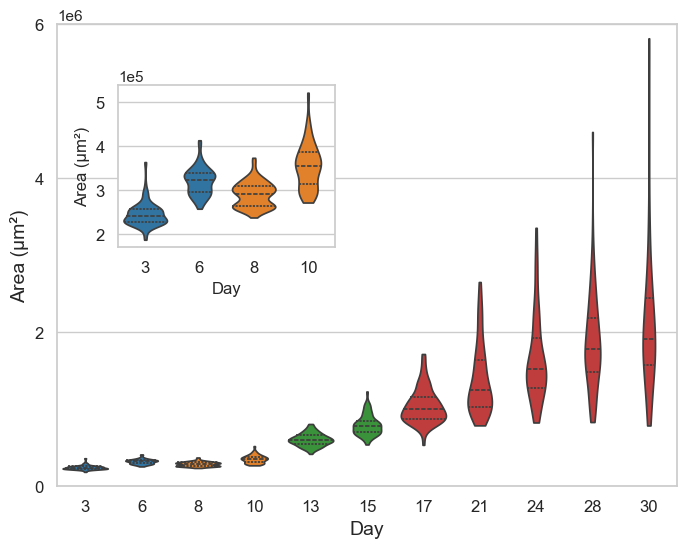

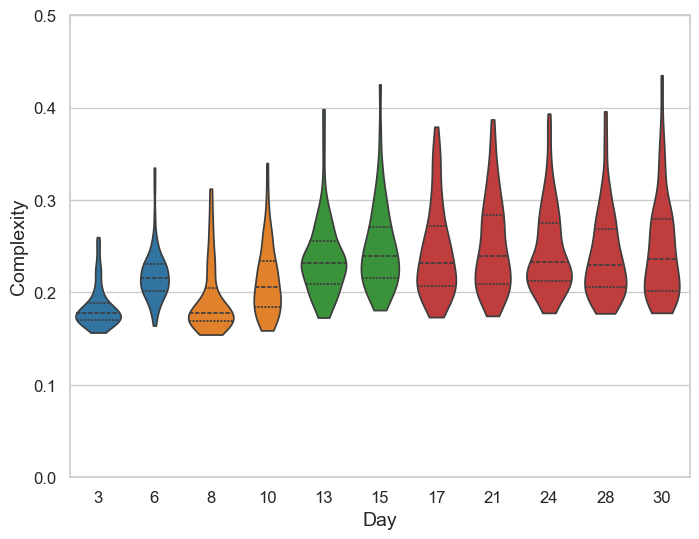

In [10]:
#Plot distributions of morphometry data (Fig. 1C and 1D)

# --- Choose Morphometry to plot ---
morph_violin = ['Area_win','Complexity_win']
y_labels = {'Area_win': 'Area (µm²)', 'Complexity_win': 'Complexity'}

sns.set(style="whitegrid")

# Define font sizes
title_fontsize = 16
label_fontsize = 14
tick_fontsize = 12


for i, var in enumerate(morph_violin):
    fig, ax = plt.subplots(figsize=(8, 6))

    sns.violinplot(
        data=df, x='Day', y=var, ax=ax,  # Use 'Day' for x-axis
        palette=phase_colors, inner="quartile", cut=0, hue='Phase', legend=False,
        bw_method=None # Remove smoothing
    )
    ax.set_xlabel("Day", fontsize=label_fontsize)
    ax.set_ylabel(y_labels.get(var, var), fontsize=label_fontsize)
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)


    # Apply scientific notation to y-axis if the variable is 'Area'
    if var == 'Area_win':
        ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))  # notação científica


    # --- Creating the embedded chart (inset) ---
    # Ensure inset is only created for the 'Area' plot
    if var == 'Area_win':
        from mpl_toolkits.axes_grid1.inset_locator import inset_axes

        ax_inset = inset_axes(ax, width="35%", height="35%", loc="upper left", borderpad=4)

        df_inicial = df[df['Day'].isin([3, 6, 8, 10])]

        # Create palette for inset based on phases present in df_inicial
        phases_in_inset = sorted(df_inicial['Phase'].unique())
        palette_inset = {phase: phase_colors[phase] for phase in phases_in_inset if phase in phase_colors}


        sns.violinplot(
            data=df_inicial, x="Day", y=var, hue="Phase", # Corrected capitalization to 'Phase'
            dodge=False, palette=palette_inset, inner="quartile", cut=0, ax=ax_inset # Use palette_inset here
        )

        ax_inset.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
        ax_inset.set_ylabel("Area (µm²)", fontsize=tick_fontsize)
        ax_inset.set_xlabel("Day", fontsize=tick_fontsize)
        ax_inset.tick_params(axis='both', which='major', labelsize=tick_fontsize)
        ax_inset.legend_.remove()


    # Set the y-axis for the Area chart
    if var == 'Area_win':
        ax.set_ylim(0, 6e6) # Corrected syntax for scientific notation
        ax.set_yticks([0, 2e6, 4e6, 6e6]) # Corrected syntax for scientific notation

    # Set the y-axis for the AR chart
    if var == 'AR_win':
        ax.set_ylim(0, 3)
        ax.set_yticks([0, 1, 2, 3])

    # Set the y-axis for the Complexity chart
    if var == 'Complexity_win':
        ax.set_ylim(0, 0.5)
        ax.set_yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5])

    # Save Figs
    if var == 'Area_win':
        plt.savefig('./Fig 1C.png', dpi=220, bbox_inches='tight')
    
    if var == 'Complexity_win':
        plt.savefig('./Fig 1D.png', dpi=220, bbox_inches='tight')
plt.show()

['Area_win', 'Circ._win', 'AR_win', 'Solidity_win', 'Complexity_win', 'Feret_win']
                     PC1       PC2
Area_win       -0.401082 -0.450471
Circ._win       0.454726 -0.271759
AR_win         -0.372914 -0.336775
Solidity_win    0.420837 -0.328987
Complexity_win -0.337109  0.610490
Feret_win      -0.450052 -0.358990
[71.   13.65]


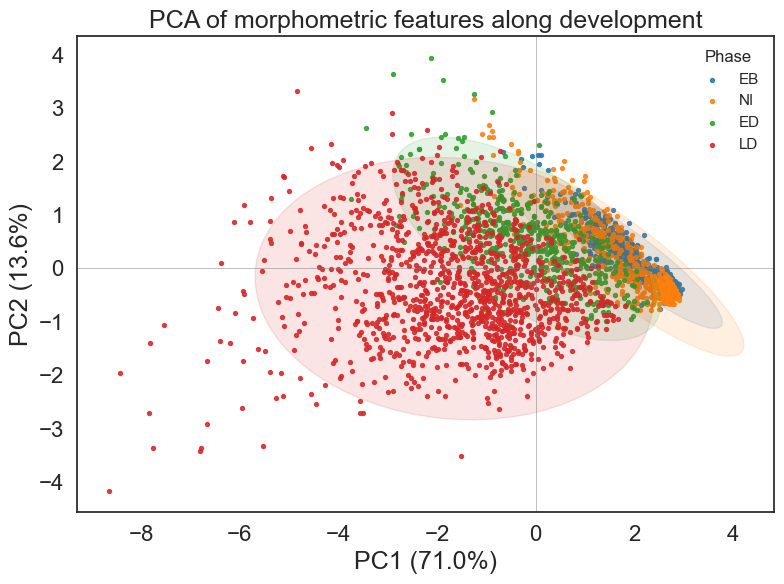

In [11]:
#Generate PCA for all days with morphometry (Fig. 1B)

plot_source_df = df.copy()
pca_cols = morph_cols_win

# Drop rows missing Phase or morphometrics
plot_df = plot_source_df.dropna(subset=['Phase'] + pca_cols).copy()

# Standardize morphometrics
scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(plot_df[pca_cols].values)

# PCA to 2 components
pca_model = PCA(n_components=2, random_state=42)
pcs = pca_model.fit_transform(X_scaled)
plot_df['PC1'] = pcs[:, 0]
plot_df['PC2'] = pcs[:, 1]

# Variance explained and loadings
expl_var_pct = pca_model.explained_variance_ratio_ * 100.0
loadings_df = pd.DataFrame(pca_model.components_.T, index=pca_cols, columns=['PC1', 'PC2'])
loadings_df.to_csv('Morph_PCA_Loadings.csv')

pca_plot_df = plot_df[['Organoid', 'Phase', 'PC1', 'PC2']].copy()
print(pca_cols)
print(loadings_df)
print(np.round(expl_var_pct, 2))

phase_order = ['EB', 'NI', 'ED', 'LD']

# 95% chi-square quantile for 2 DoF
chi2_val = chi2.ppf(0.95, df=2)

def draw_conf_ellipse_95(x_vals, y_vals, ax, color_hex='#999999', alpha_fill=0.12):
    mask = np.isfinite(x_vals) & np.isfinite(y_vals)
    x = x_vals[mask]
    y = y_vals[mask]
    if x.size < 3:
        return
    cov = np.cov(x, y)
    if np.isnan(cov).any() or cov.shape != (2, 2):
        return
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals = vals[order]
    vecs = vecs[:, order]
    theta = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    # Width/height scaled by sqrt(chi2_val) for 95% coverage
    width = 2.0 * np.sqrt(vals[0] * chi2_val)
    height = 2.0 * np.sqrt(vals[1] * chi2_val)
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    ell = Ellipse(xy=(mean_x, mean_y), width=width, height=height, angle=theta,
                  facecolor=color_hex, edgecolor=color_hex, alpha=alpha_fill)
    ax.add_patch(ell)

sns.set_theme(style='white')
plt.figure(figsize=(8, 6))
ax = plt.gca()
for ph in phase_order:
    sub = pca_plot_df[pca_plot_df['Phase'] == ph]
    if len(sub) == 0:
        continue
    ax.scatter(sub['PC1'], sub['PC2'], s=8, c=phase_colors[ph], label=ph, alpha=0.85)
    draw_conf_ellipse_95(sub['PC1'].values, sub['PC2'].values, ax, color_hex=phase_colors[ph], alpha_fill=0.12)

ax.axhline(0, color='gray', lw=0.6, alpha=0.6)
ax.axvline(0, color='gray', lw=0.6, alpha=0.6)
ax.set_xlabel('PC1 (' + str(np.round(expl_var_pct[0], 1)) + '%)', fontsize=18)
ax.set_ylabel('PC2 (' + str(np.round(expl_var_pct[1], 1)) + '%)', fontsize=18)
ax.set_title('PCA of morphometric features along development', fontsize=18)
ax.tick_params(axis='both', labelsize=16)

handles, labels = ax.get_legend_handles_labels()
ordered_handles = []
ordered_labels = []
for ph in phase_order:
    if ph in labels:
        idx = labels.index(ph)
        ordered_handles.append(handles[idx])
        ordered_labels.append(ph)
ax.legend(ordered_handles, ordered_labels, title='Phase', frameon=False)
plt.tight_layout()
plt.savefig('./Fig 1B.png', dpi=220, bbox_inches='tight')
plt.show()

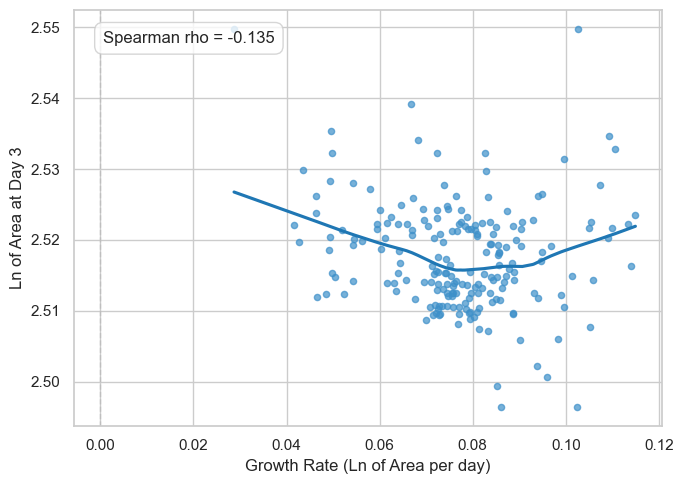

Spearman Ln of Area at Day 3: rho = -0.13534910655504412, p = 0.05478450308126114


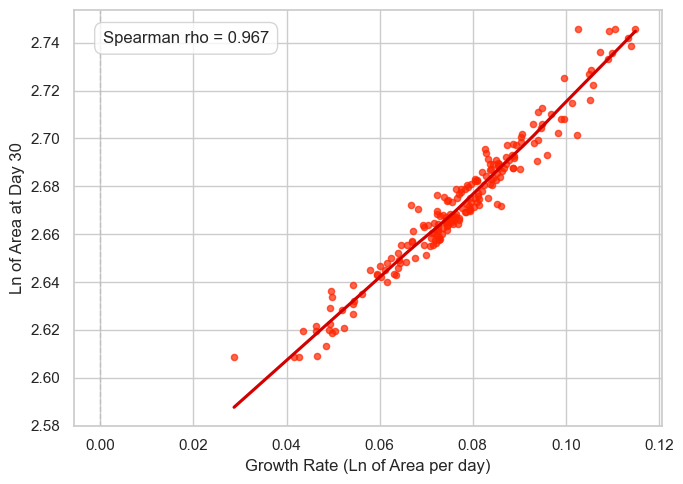

Spearman Ln of Area at Day 30: rho = 0.9673916445953029, p = 3.069760193725583e-121


In [35]:
# Spearman correlations between GrowthRate_overall_ln and ln(Area) at Day 3 and Day 30 (Fig 2E and 2F)

# Prepare organoid-level overall growth rate ln
org_overall = df[['Organoid','GrowthRate_overall_ln']].drop_duplicates('Organoid')

# Get Area at Day 3 and Day 30 per organoid, then take natural log
d3 = df[df['Day'] == 3][['Organoid','Area_win_log']].dropna().drop_duplicates('Organoid')
d3['Area_Day3'] = np.log(d3['Area_win_log'])

d30 = df[df['Day'] == 30][['Organoid','Area_win_log']].dropna().drop_duplicates('Organoid')
d30['Area_Day30'] = np.log(d30['Area_win_log'])

# Merge
merged_log = org_overall.merge(d3[['Organoid','Area_Day3']], on='Organoid', how='left')
merged_log = merged_log.merge(d30[['Organoid','Area_Day30']], on='Organoid', how='left')

# Helper to compute spearman and plot with LOWESS for visual trend
sns.set_theme(style='whitegrid')

for col, label, scatter_col, line_col, fig_name in [('Area_Day3','Ln of Area at Day 3','#3e90c9','#1f77b4','./Fig 3E.png'), ('Area_Day30','Ln of Area at Day 30','#ff2400','#D30000', './Fig 3F.png')]:
    sub = merged_log[['GrowthRate_overall_ln', col]].dropna()
    rho = np.nan
    pval = np.nan
    if sub.shape[0] >= 3:
        rho, pval = spearmanr(sub['GrowthRate_overall_ln'], sub[col])
    plt.figure(figsize=(7,5))
    ax = sns.regplot(data=sub, x='GrowthRate_overall_ln', y=col, scatter_kws={'s':20, 'alpha':0.7, 'color': scatter_col}, line_kws={'color':line_col}, lowess=True)
    ax.axvline(0, color='#bbbbbb', lw=1, ls='--', alpha=0.8)
    ax.set_xlabel('Growth Rate (Ln of Area per day)')
    ax.set_ylabel(label)
    text_str = 'Spearman rho = ' + (str(np.round(rho,3)) if np.isfinite(rho) else 'NA')
    ax.text(x=0.05, y=0.95,
            s=text_str,
            transform=ax.transAxes,
            fontsize=12,
            fontweight='normal',
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='#cccccc')
    )
    plt.tight_layout()
    plt.savefig(fig_name, dpi=220, bbox_inches='tight')
    plt.show()
    print('Spearman ' + label + ': rho = ' + (str(rho) if np.isfinite(rho) else 'NA') + ', p = ' + (str(pval) if np.isfinite(pval) else 'NA'))

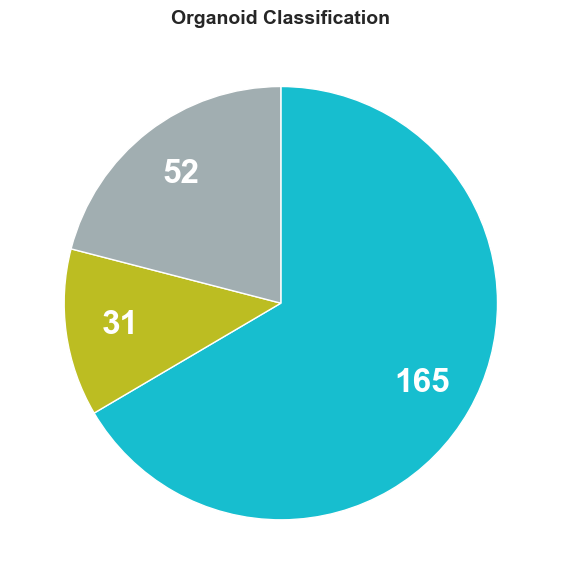

Total Organoids Classified:  248


In [13]:
# Prepare classified organoids at the organoid level (Fig. 2D)

pie_df = df[['Organoid','Classification']].drop_duplicates('Organoid')

pie_labels = ['Good','Bad','Uncertain']

pie_g = int((pie_df['Classification'] == 'Good').sum())
pie_b = int((pie_df['Classification'] == 'Bad').sum())
pie_u = int(pie_df['Classification'].str.contains('Uncertain', na=False).sum())

pie_counts = [pie_g, pie_b, pie_u]
pie_total = sum(pie_counts)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

# Define a simple function to format the label as the absolute value
# 'pct' is the percentage automatically calculated by matplotlib
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        # Return empty string if value is 0 to avoid clutter, else return value
        return '{v:d}'.format(v=val) if val > 0 else ''
    return my_autopct

wedges, text_labels, autotexts = ax.pie(
    pie_counts,
    #labels=pie_labels,
    colors=[classif_colors['Good'], classif_colors['Bad'], classif_colors['Uncertain']],
    autopct=make_autopct(pie_counts),
    startangle=90,
    counterclock=False,
    pctdistance=0.75
)

# Title and note
ax.set_title('Organoid Classification', fontsize=14, weight='bold')

# Style label texts (Outside labels: Good, Bad, etc.)
for t in text_labels:
    t.set_fontsize(12)
    t.set_weight('bold')

# Style numeric texts (Inside labels: the counts)
for t in autotexts:
    t.set_fontsize(24)
    t.set_weight('bold')
    t.set_color('white')

plt.tight_layout()
plt.savefig('./Fig 2D.png', dpi=220, bbox_inches='tight')
plt.show()

print('Total Organoids Classified: ',pie_total)

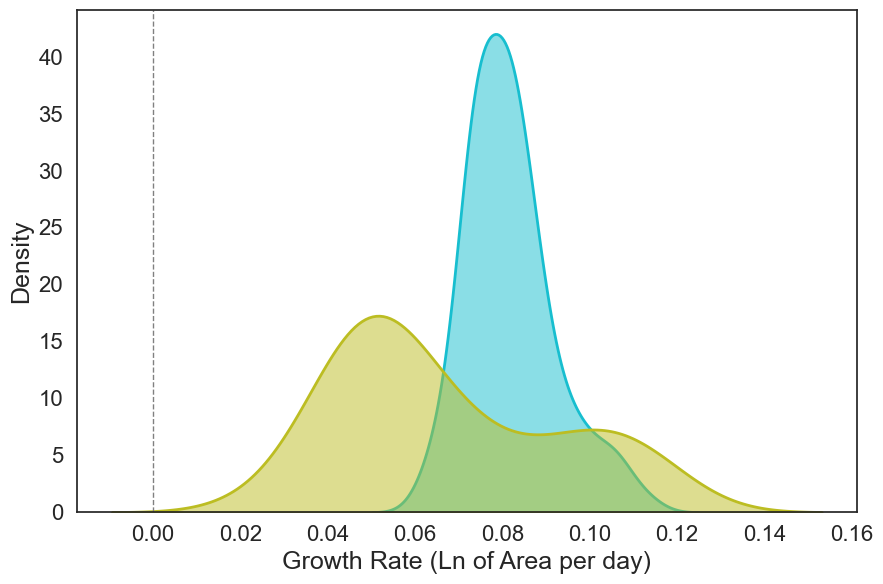

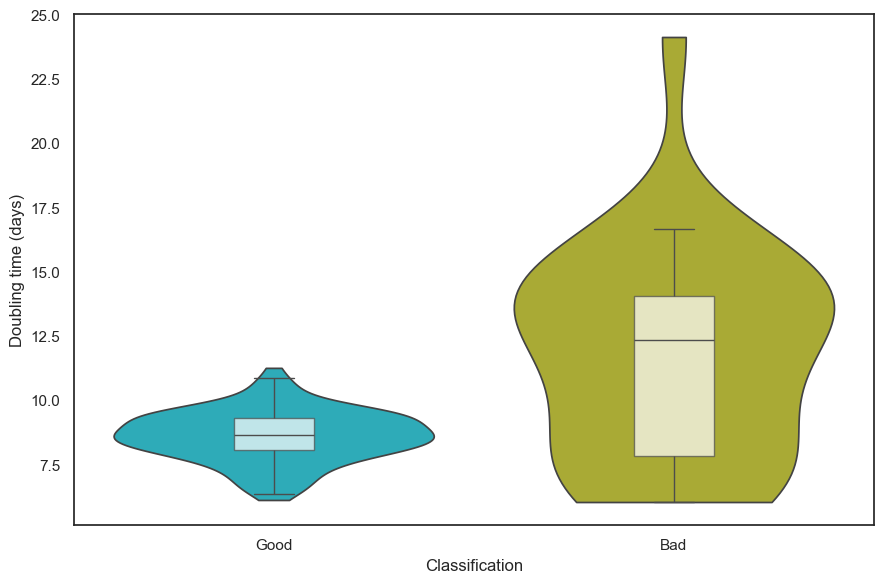

Classification
Good    126
Bad      29
Name: count, dtype: int64
Classification
Good    126
Bad      29
Name: count, dtype: int64


In [14]:
# Distribution of the growth rate and doubling time for Good and Bad organoids (KDE is Fig. 3D, Doubling time probably won't be published)
# Use organoid-level overall rate (same across rows); drop duplicates
org_metrics = df_sub [['Organoid','Classification','GrowthRate_overall_ln','DoublingTime_overall_days']].drop_duplicates('Organoid')
org_metrics = org_metrics[np.isfinite(org_metrics['GrowthRate_overall_ln'])]

# KDE overlay of GrowthRate_overall_ln
sns.set_theme(style='white')
plt.figure(figsize=(9,6))
sns.kdeplot(data=org_metrics[org_metrics['Classification']=='Good'], x='GrowthRate_overall_ln', fill=True, alpha=0.5, palette=classif_colors, hue='Classification', linewidth=2, label='Good', legend=False)
sns.kdeplot(data=org_metrics[org_metrics['Classification']=='Bad'], x='GrowthRate_overall_ln', fill=True, alpha=0.5, palette=classif_colors, hue='Classification', linewidth=2, label='Bad', legend=False)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Growth Rate (Ln of Area per day)', fontsize=18)
plt.ylabel('Density', fontsize=18)
plt.title('')
#plt.legend(title='Classification', fontsize=16, title_fontsize=16)
plt.tick_params(axis='both', labelsize=16)
plt.tight_layout()
plt.savefig('./Fig 3D.png', dpi=220, bbox_inches='tight')
plt.show()

# Doubling time comparison: side-by-side violin + box overlay for Good vs Bad
dt_df = org_metrics.copy()
# Only positive rates have defined doubling times (already computed); ensure finite
dt_df = dt_df[np.isfinite(dt_df['DoublingTime_overall_days'])]

plt.figure(figsize=(9,6))
sns.violinplot(data=dt_df, x='Classification', y='DoublingTime_overall_days', palette=classif_colors, hue='Classification', cut=0, inner=None)
sns.boxplot(data=dt_df, x='Classification', y='DoublingTime_overall_days', width=0.2, showcaps=True, boxprops={'facecolor':'white','alpha':0.7}, showfliers=False)
plt.ylabel('Doubling time (days)')
plt.xlabel('Classification')
plt.title('')
plt.tight_layout()
plt.show()

# Print quick counts for transparency
print(org_metrics['Classification'].value_counts())
print(dt_df['Classification'].value_counts())

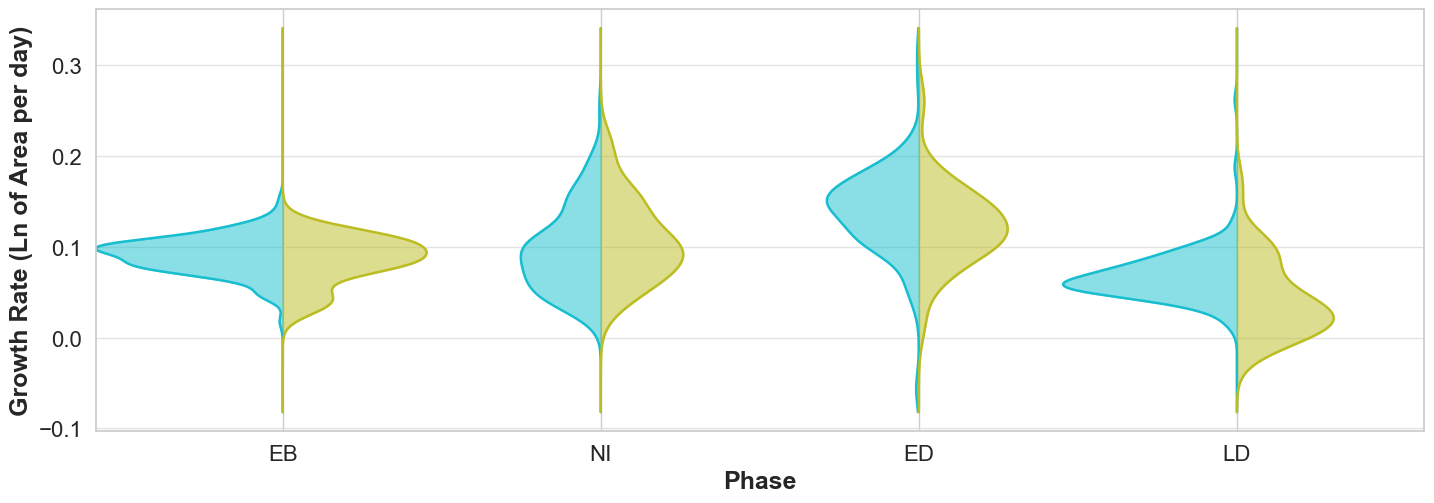

In [15]:
# mirrored KDE of growth rate by Phase (Supp Fig S2)

gr_phase = df_sub[['Organoid','Classification','Phase','GrowthRate_phase_ln']].drop_duplicates(['Organoid','Phase'])
phase_order = ['EB','NI','ED','LD']

sns.set_theme(style='whitegrid')
plt.figure(figsize=(14.5, 5.2))
ax = plt.gca()
ax.set_axisbelow(True)
ax.grid(axis='y', color='#dddddd', alpha=0.8)

# Common y grid
all_vals = gr_phase['GrowthRate_phase_ln'].dropna().values
ymin = float(np.nanmin(all_vals))
ymax = float(np.nanmax(all_vals))
pad = 0.06 * (ymax - ymin)
y_grid = np.linspace(ymin - pad, ymax + pad, 260)

# Even wider spacing and larger left offset for EB
spacing = 1.7
left_offset = 1.2
x_positions = {ph: (i * spacing) + left_offset for i, ph in enumerate(phase_order)}

# Global width normalization across all densities
d_list = []
for ph in phase_order:
    gr_sub = gr_phase[gr_phase['Phase']==ph]
    for cls in ['Good','Bad']:
        v = gr_sub[gr_sub['Classification']==cls]['GrowthRate_phase_ln'].dropna().values
        if v.size >= 3 and np.nanstd(v) > 0:
            d = gaussian_kde(v)(y_grid)
            d_list.append(d)

global_max = float(np.nanmax(np.concatenate(d_list))) if len(d_list)>0 else 1.0

# Draw mirrored densities with more whitespace
for ph in phase_order:
    gr_sub = gr_phase[gr_phase['Phase']==ph]
    g_vals = gr_sub[gr_sub['Classification']=='Good']['GrowthRate_phase_ln'].dropna().values
    b_vals = gr_sub[gr_sub['Classification']=='Bad']['GrowthRate_phase_ln'].dropna().values
    x0 = x_positions[ph]

    dens_g = gaussian_kde(g_vals)(y_grid) if g_vals.size>=3 and np.nanstd(g_vals)>0 else None
    dens_b = gaussian_kde(b_vals)(y_grid) if b_vals.size>=3 and np.nanstd(b_vals)>0 else None

    if dens_g is not None:
        dens_g = dens_g / global_max
        ax.fill_betweenx(y_grid, x0 - dens_g, x0, color=classif_colors['Good'], alpha=0.5)
        ax.plot(x0 - dens_g, y_grid, color=classif_colors['Good'], lw=1.8)
    if dens_b is not None:
        dens_b = dens_b / global_max
        ax.fill_betweenx(y_grid, x0, x0 + dens_b, color=classif_colors['Bad'], alpha=0.5)
        ax.plot(x0 + dens_b, y_grid, color=classif_colors['Bad'], lw=1.8)

# Ticks and expanded limits to emphasize whitespace
ax.set_xticks([x_positions[p] for p in phase_order])
ax.set_xticklabels(phase_order)
ax.set_xlim(min(x_positions.values()) - 1.0, max(x_positions.values()) + 1.0)
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

ax.set_xlabel('Phase', fontsize=18, weight='bold')
ax.set_ylabel('Growth Rate (Ln of Area per day)', fontsize=18, weight='bold')
ax.set_title('', fontsize=14, weight='bold')
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=classif_colors['Good'], edgecolor=classif_colors['Good'], alpha=0.6, label='Good'),
                  Patch(facecolor=classif_colors['Bad'], edgecolor=classif_colors['Bad'], alpha=0.6, label='Bad')]
#ax.legend(handles=legend_handles, title='Classification', frameon=False, loc='upper right', fontsize=14, title_fontsize=14)
plt.tight_layout()
plt.savefig('./Supp Fig S2.png', dpi=220, bbox_inches='tight')
plt.show()

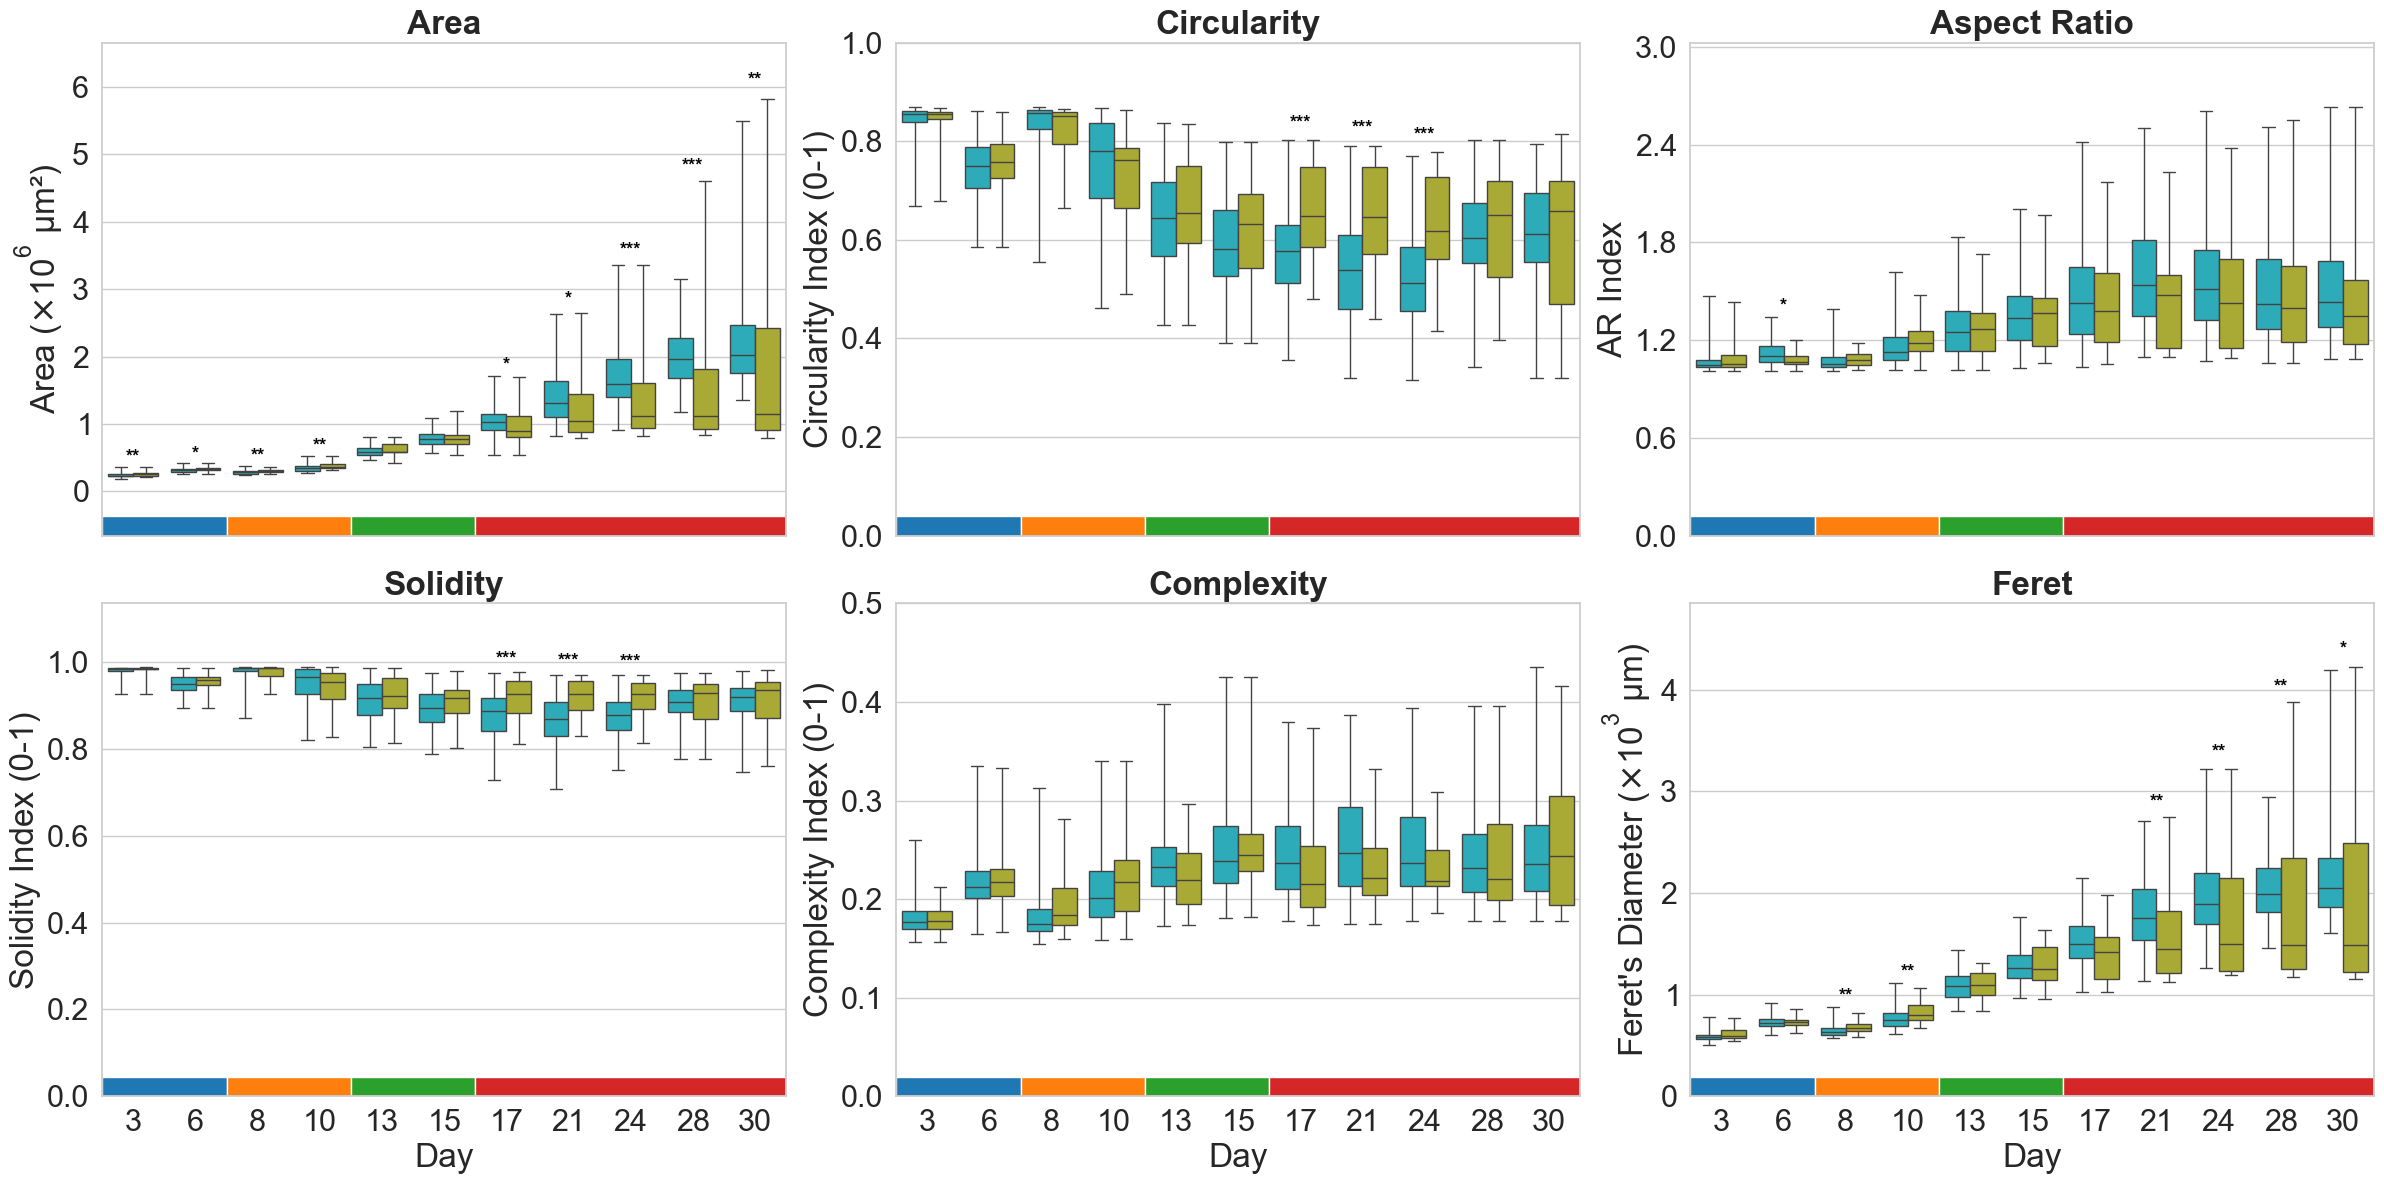

In [16]:
#Boxplots of morphometric features by day for good and bad organoids (Fig 3C)

# Helper to add rectangles
def add_phase_rectangles_bottom(ax, days_sorted_local, frac_height=0.06):
    day_to_pos = {d: i for i, d in enumerate(days_sorted_local)}

    def rect_for_phase(day_start, day_end, color):
        if (day_start in day_to_pos) and (day_end in day_to_pos):
            x0 = day_to_pos[day_start] - 0.5
            x1 = day_to_pos[day_end] + 0.5
            width = x1 - x0
            y0, y1 = ax.get_ylim()
            y_height = (y1 - y0) * frac_height
            rect = Rectangle((x0, y0), width, y_height,
                             facecolor=color, alpha=1.0, zorder=0)
            ax.add_patch(rect)

    # Assume phase_colors is defined globally
    if 'phase_colors' in globals():
        rect_for_phase(3, 6, phase_colors.get('EB', 'blue'))
        rect_for_phase(8, 10, phase_colors.get('NI', 'orange'))
        rect_for_phase(13, 15, phase_colors.get('ED', 'green'))
        rect_for_phase(17, 30, phase_colors.get('LD', 'red'))

# Helper for significance symbols
def q_to_symbol(q):
    if pd.isna(q):
        return ''
    if q < 0.001:
        return '***'
    if q < 0.01:
        return '**'
    if q < 0.05:
        return '*'
    return ''

features_raw = [c for c in morph_cols_win if c in df.columns]
features_resid = [f + '_resid' for f in features_raw if f != 'Area_win']

# Create a list of columns to maintain (Raw + Resid)
cols_to_keep = ['Organoid', 'Day', 'Classification'] + features_raw
cols_to_keep += [c for c in features_resid if c in df.columns]

# Create a work subset ensuring numerical values
df_work = df[cols_to_keep].dropna(subset=['Day', 'Classification']).copy()
days_sorted = sorted(df_work['Day'].dropna().unique())

# ---------------------------------------------------------
# STATISTIC (MWU + FDR)
# ---------------------------------------------------------

# 1. MWU + FDR for Raw values
records = []

df_stats_raw = df_work[df_work['Classification'].isin(['Good', 'Bad'])].copy()

for feat in features_raw:

    for d, grp in df_stats_raw.groupby('Day'):
        g = grp.loc[grp['Classification'] == 'Good', feat].dropna()
        b = grp.loc[grp['Classification'] == 'Bad', feat].dropna()

        n_good = len(g)
        n_bad = len(b)

        if len(g) >= 3 and len(b) >= 3:
            try:
                stat, p = mannwhitneyu(g, b, alternative='two-sided')
            except ValueError:
                p = np.nan
        else:
            p = np.nan
        records.append({'feature': feat, 'day': d, 'p_raw': p, 'n_good': len(g), 'n_bad': len(b)})

raw_tab = pd.DataFrame(records)
mask = raw_tab['p_raw'].notna()
if mask.sum() > 0:
    reject, qvals, _, _ = multipletests(raw_tab.loc[mask, 'p_raw'].values, method='fdr_bh')
    raw_tab.loc[mask, 'reject_fdr'] = reject
    raw_tab.loc[mask, 'qval'] = qvals
else:
    raw_tab['reject_fdr'] = np.nan
    raw_tab['qval'] = np.nan

# 2. MWU + FDR for residualized values
resid_records = []

df_stats_resid = df_work[df_work['Classification'].isin(['Good', 'Bad'])].copy()

for feat_resid in features_resid:
    base_feat = feat_resid.replace('_resid', '')

    for d, grp in df_stats_resid.groupby('Day'):
        g = grp.loc[grp['Classification'] == 'Good', feat_resid].dropna()
        b = grp.loc[grp['Classification'] == 'Bad', feat_resid].dropna()

        n_good = len(g)
        n_bad = len(b)

        if len(g) >= 3 and len(b) >= 3:
            try:
                stat, p = mannwhitneyu(g, b, alternative='two-sided')
            except ValueError:
                p = np.nan
        else:
            p = np.nan
        resid_records.append({'feature': base_feat, 'day': d, 'p_res': p, 'n_good': len(g), 'n_bad': len(b)})

res_tab = pd.DataFrame(resid_records)
mask = res_tab['p_res'].notna()
if mask.sum() > 0:
    reject, qvals, _, _ = multipletests(res_tab.loc[mask, 'p_res'].values, method='fdr_bh')
    res_tab.loc[mask, 'reject_fdr'] = reject
    res_tab.loc[mask, 'qval'] = qvals
else:
    res_tab['reject_fdr'] = np.nan

# ---------------------------------------------------------
# PLOT 1: Boxplots RAW
# ---------------------------------------------------------
features_to_plot_raw = [c for c in features_raw if c in df_stats_raw.columns]
feat_title_ylabel = {
    'Area_win': ('Area', 'Area ({} µm²)'),
    'Circ._win': ('Circularity', 'Circularity Index (0-1)'),
    'AR_win': ('Aspect Ratio', 'AR Index'),
    'Solidity_win': ('Solidity', 'Solidity Index (0-1)'),
    'Complexity_win': ('Complexity', 'Complexity Index (0-1)'),
    'Feret_win': ('Feret', "Feret's Diameter ({} µm)"),
}

cols = 3
rows = int(np.ceil(max(1, len(features_to_plot_raw)) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(8*cols, 6*rows), sharex=True)
axes = np.array(axes).reshape(rows, cols)
for ax in axes.ravel(): ax.axis('off')

for i, feat in enumerate(features_to_plot_raw):
    r = i // cols
    c = i % cols
    ax = axes[r, c]
    ax.axis('on')

    sns.boxplot(
        data=df_stats_raw, x='Day', y=feat, hue='Classification',
        whis=[0, 100], showcaps=True, dodge=True, fliersize=3,
        palette=classif_colors, ax=ax
    )
    
    
    # Y-limits and extra padding for Area_win
    vals = pd.to_numeric(df_work[feat], errors='coerce').dropna()
    if len(vals) > 0:
        data_min = float(np.nanmin(vals))
        data_max = float(np.nanmax(vals))
        if np.isfinite(data_max):
            pad_factor = 0.15
            if feat == 'Area_win':
                span = max(data_max - data_min, 1e-6)
                lower = data_min - pad_factor * span  # extra padding below
                upper = data_max + pad_factor * span
                ax.set_ylim(lower, upper)
            else:
                upper = data_max + pad_factor * (data_max - min(data_min, 0))
                if data_min >= 0:
                    ax.set_ylim(0, upper)
                else:
                    ax.set_ylim(data_min, upper)

    # Axis formatting
    if feat in ['Area_win', 'Feret_win']:
        ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
        ax.ticklabel_format(axis='y', style='sci', scilimits=(-2, 3))
        plt.draw()
        sci_not = ax.yaxis.get_offset_text().get_text()
        ax.yaxis.get_offset_text().set_visible(False)
    else:
        sci_not_val = ""
        ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=False))
        ax.yaxis.set_major_locator(mticker.MaxNLocator(6))
        ax.yaxis.get_offset_text().set_visible(False)
    
    title_text, ylabel_template = feat_title_ylabel.get(feat, (feat + ' by Day', feat))
      
    if "{}" in ylabel_template:
      ylabel_text = ylabel_template.format(sci_not)
    else:
      ylabel_text = ylabel_template
      
    ax.set_title(title_text, fontsize=24, weight='bold')
    ax.set_xlabel('Day', fontsize=24)
    ax.set_ylabel(ylabel_text, fontsize=24)
    ax.tick_params(axis='both', which='major', labelsize=22)
    ax.get_legend().remove()
    #ax.legend(title='Classification', fontsize=22, title_fontsize=22)


    # q-asterisks
    for xd, d in enumerate(days_sorted):
        row_q = raw_tab[(raw_tab['feature'] == feat) & (raw_tab['day'] == d)]
        q = row_q['qval'].iloc[0] if len(row_q) > 0 and 'qval' in row_q.columns else np.nan
        sym = q_to_symbol(q)

        if sym:
            subd_day = df_stats_raw[df_stats_raw['Day'] == d]
            day_vals = pd.to_numeric(subd_day[feat], errors='coerce').dropna()
            if len(day_vals) > 0:
                local_max = float(np.nanmax(day_vals))
                local_std = float(np.nanstd(day_vals)) if np.isfinite(np.nanstd(day_vals)) else 0.0
                span_all = float(np.nanmax(vals) - np.nanmin(vals))
                local_yoff = 0.15 * local_std if local_std > 0 else 0.05 * span_all
                y_pos = local_max + local_yoff

                ax.text(xd, y_pos, sym, ha='center', va='bottom', fontsize=13,
                        color='black', weight='bold')

                # Adjust y-lim to avoid asterisk out of graph
                cur_ymin, cur_ymax = ax.get_ylim()
                if y_pos > cur_ymax:
                    ax.set_ylim(cur_ymin, y_pos * 1.05)

    add_phase_rectangles_bottom(ax, days_sorted, frac_height=0.04)
    #if not (r==0 and c==0):
        #if ax.get_legend(): ax.get_legend().remove()

plt.tight_layout()
plt.savefig('./Fig 3C.png', dpi=220, bbox_inches='tight')
plt.show()

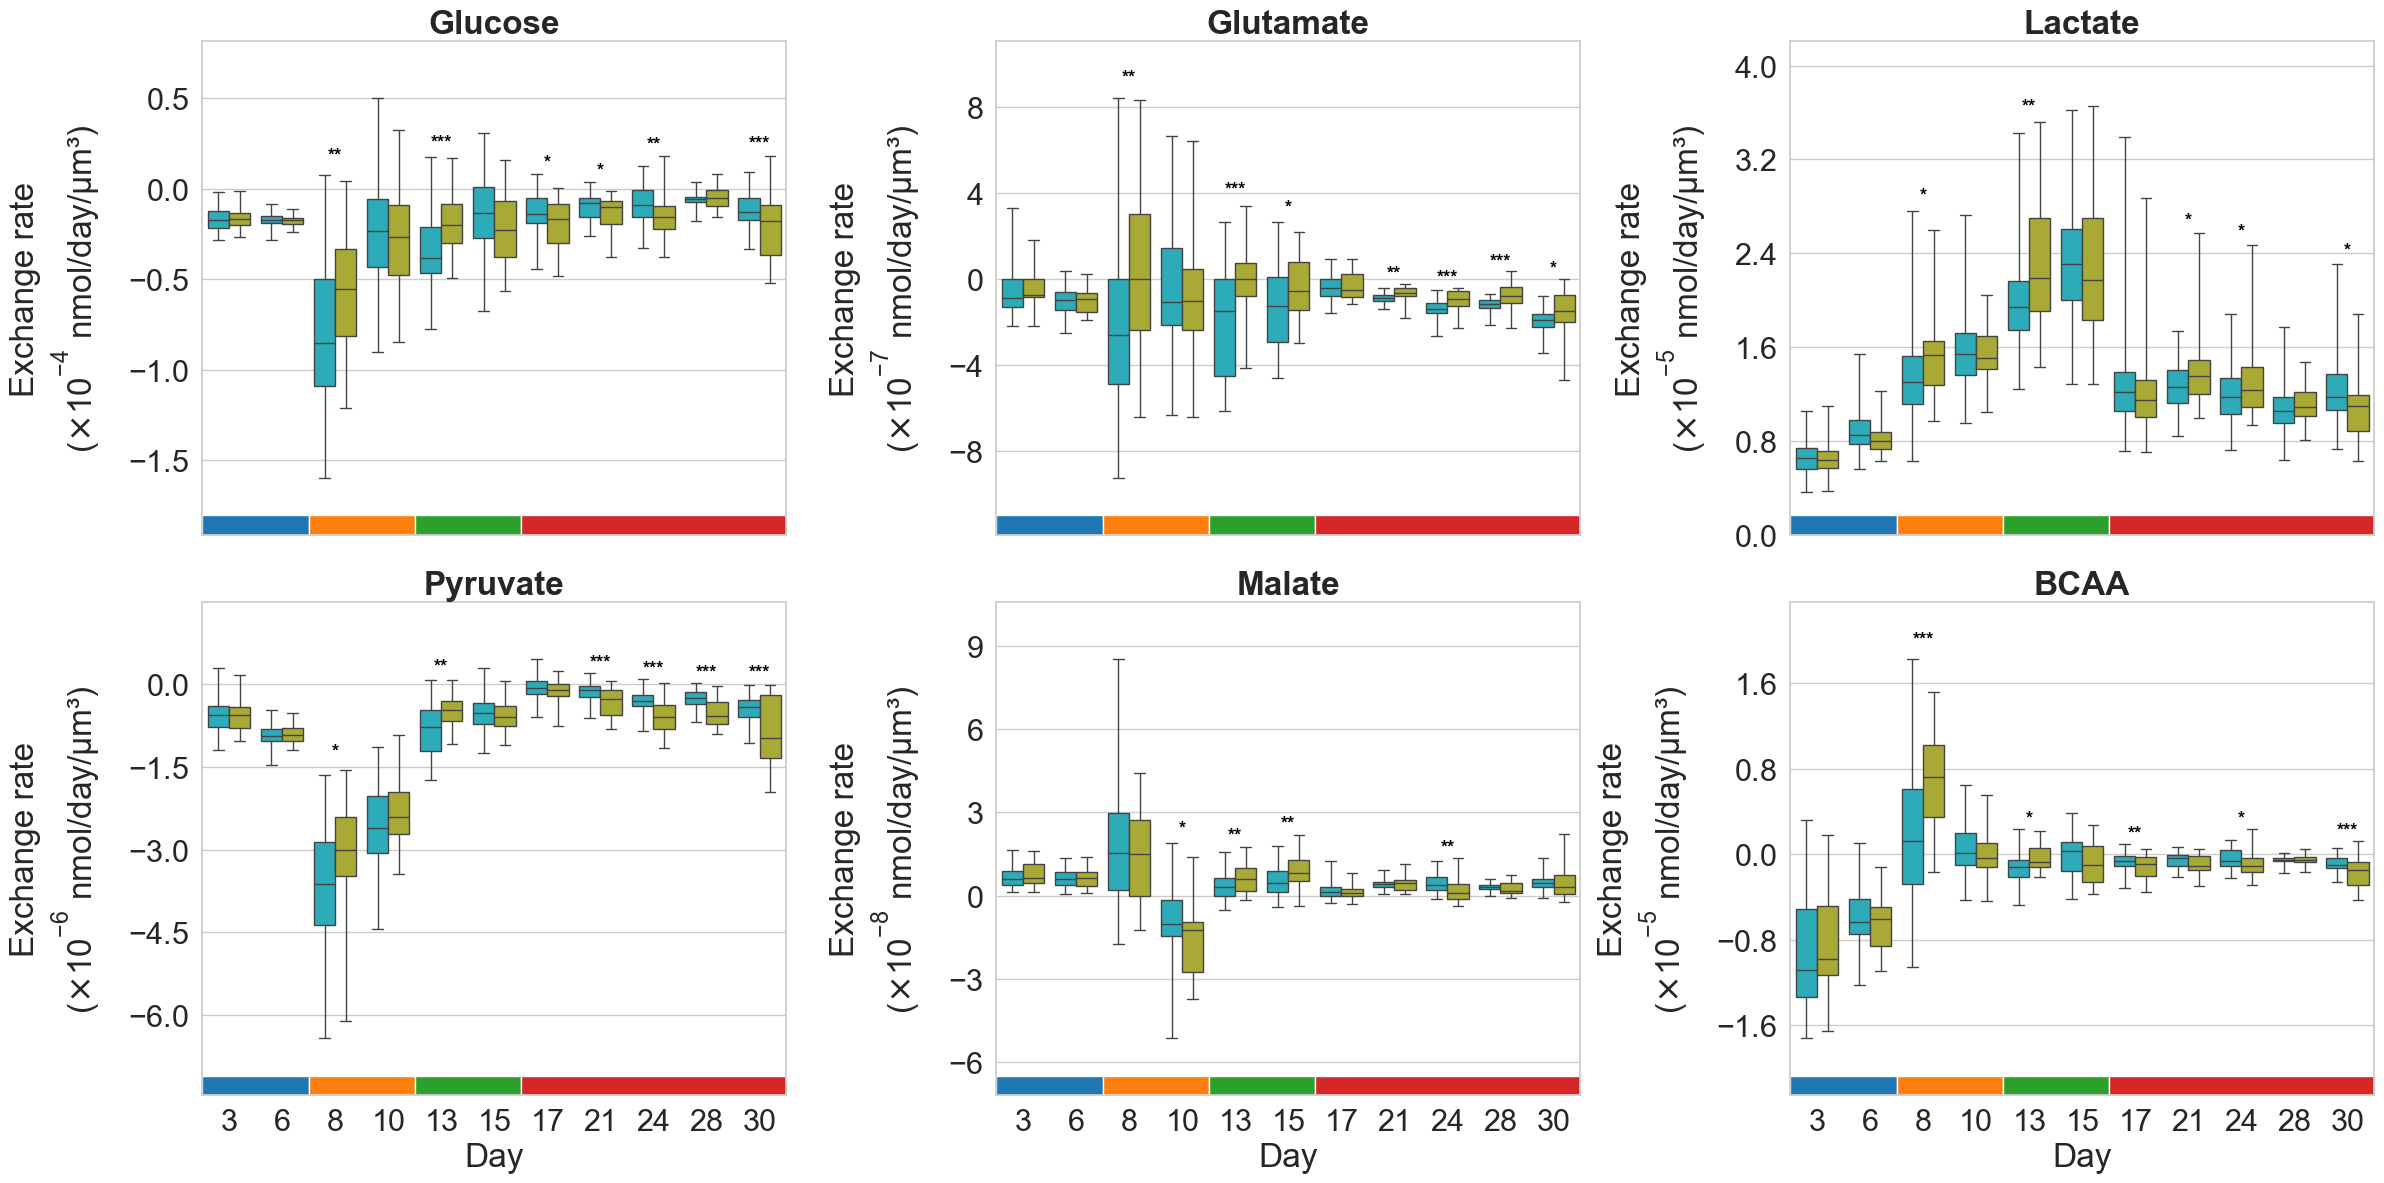

In [17]:
#Boxplots of metabolite features by day for good and bad organoids (Fig 4C)

# Helper to add rectangles
def add_phase_rectangles_bottom(ax, days_sorted_local, frac_height=0.06):
    day_to_pos = {d: i for i, d in enumerate(days_sorted_local)}

    def rect_for_phase(day_start, day_end, color):
        if (day_start in day_to_pos) and (day_end in day_to_pos):
            x0 = day_to_pos[day_start] - 0.5
            x1 = day_to_pos[day_end] + 0.5
            width = x1 - x0
            y0, y1 = ax.get_ylim()
            y_height = (y1 - y0) * frac_height
            rect = Rectangle((x0, y0), width, y_height,
                             facecolor=color, alpha=1.0, zorder=0)
            ax.add_patch(rect)

    # Assume phase_colors is defined globally
    if 'phase_colors' in globals():
        rect_for_phase(3, 6, phase_colors.get('EB', 'blue'))
        rect_for_phase(8, 10, phase_colors.get('NI', 'orange'))
        rect_for_phase(13, 15, phase_colors.get('ED', 'green'))
        rect_for_phase(17, 30, phase_colors.get('LD', 'red'))

# Helper for significance symbols
def q_to_symbol(q):
    if pd.isna(q):
        return ''
    if q < 0.001:
        return '***'
    if q < 0.01:
        return '**'
    if q < 0.05:
        return '*'
    return ''

features_raw = [c for c in metab_cols_win_vol_norm if c in df.columns]
features_resid = [f + '_resid' for f in features_raw if f != 'Area_win']

# Create a list of columns to maintain (Raw + Resid)
cols_to_keep = ['Organoid', 'Day', 'Classification'] + features_raw
cols_to_keep += [c for c in features_resid if c in df.columns]

# Create a work subset ensuring numerical values
df_work = df[cols_to_keep].dropna(subset=['Day', 'Classification']).copy()
days_sorted = sorted(df_work['Day'].dropna().unique())

# ---------------------------------------------------------
# STATISTIC (T-test + FDR)
# ---------------------------------------------------------

# 1. T-test + FDR for Raw values
records = []

df_stats_raw = df_work[df_work['Classification'].isin(['Good', 'Bad'])].copy()

for feat in features_raw:

    for d, grp in df_stats_raw.groupby('Day'):
        g = grp.loc[grp['Classification'] == 'Good', feat].dropna()
        b = grp.loc[grp['Classification'] == 'Bad', feat].dropna()

        n_good = len(g)
        n_bad = len(b)

        if n_good >= 3 and n_bad >= 3:
            try:
                test_res = ttest_ind(g, b, equal_var=True, nan_policy='omit')
                p = test_res.pvalue
                tstat = test_res.statistic
            except Exception:
                p = np.nan
                tstat = np.nan
        else:
            p = np.nan
            tstat = np.nan

        records.append({
            'feature': feat,
            'day': d,
            'p_raw': p,
            't_stat': tstat,
            'n_good': n_good,
            'n_bad': n_bad,
            'mean_good': g.mean() if n_good > 0 else np.nan,
            'mean_bad': b.mean() if n_bad > 0 else np.nan
        })

raw_tab = pd.DataFrame(records)
mask = raw_tab['p_raw'].notna()
if mask.sum() > 0:
    reject, qvals, _, _ = multipletests(raw_tab.loc[mask, 'p_raw'].values, method='fdr_bh')
    raw_tab.loc[mask, 'reject_fdr'] = reject
    raw_tab.loc[mask, 'qval'] = qvals
else:
    raw_tab['reject_fdr'] = np.nan
    raw_tab['qval'] = np.nan

# 2. T-test + FDR for residualized values
resid_records = []

df_stats_resid = df_work[df_work['Classification'].isin(['Good', 'Bad'])].copy()

for feat_resid in features_resid:
    base_feat = feat_resid.replace('_resid', '')

    for d, grp in df_stats_resid.groupby('Day'):
        g = grp.loc[grp['Classification'] == 'Good', feat_resid].dropna()
        b = grp.loc[grp['Classification'] == 'Bad', feat_resid].dropna()

        n_good = len(g)
        n_bad = len(b)

        if n_good >= 3 and n_bad >= 3:
            try:
                test_res = ttest_ind(g, b, equal_var=True, nan_policy='omit')
                p = test_res.pvalue
                tstat = test_res.statistic
            except Exception:
                p = np.nan
                tstat = np.nan
        else:
            p = np.nan
            tstat = np.nan

        resid_records.append({
            'feature': base_feat,
            'day': d,
            'p_raw': p,
            't_stat': tstat,
            'n_good': n_good,
            'n_bad': n_bad,
            'mean_good': g.mean() if n_good > 0 else np.nan,
            'mean_bad': b.mean() if n_bad > 0 else np.nan
        })

res_tab = pd.DataFrame(resid_records)
mask = res_tab['p_raw'].notna()
if mask.sum() > 0:
    reject, qvals, _, _ = multipletests(res_tab.loc[mask, 'p_raw'].values, method='fdr_bh')
    res_tab.loc[mask, 'reject_fdr'] = reject
    res_tab.loc[mask, 'qval'] = qvals
else:
    res_tab['reject_fdr'] = np.nan

# ---------------------------------------------------------
# PLOT 1: Boxplots RAW
# ---------------------------------------------------------
features_to_plot_raw = [c for c in features_raw if c in df_stats_raw.columns]

feat_title_ylabel = {
    'GlucoseGlo_win_vol_norm': ('Glucose', 'Exchange rate ({} nmol/day/µm³)'),
    'GlutamateGlo_win_vol_norm': ('Glutamate', 'Exchange rate ({} nmol/day/µm³)'),
    'PyruvateGlo_win_vol_norm': ('Pyruvate', 'Exchange rate ({} nmol/day/µm³)'),
    'MalateGlo_win_vol_norm': ('Malate', 'Exchange rate ({} nmol/day/µm³)'),
    'BCAAGlo_win_vol_norm': ('BCAA', 'Exchange rate ({} nmol/day/µm³)'),
    'LactateGlo_win_vol_norm': ('Lactate', 'Exchange rate ({} nmol/day/µm³)'),
}

cols = 3
rows = int(np.ceil(max(1, len(features_to_plot_raw)) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(8*cols,6*rows), sharex=True)
axes = np.array(axes).reshape(rows, cols)
for ax in axes.ravel(): ax.axis('off')

for i, feat in enumerate(features_to_plot_raw):
    r = i // cols
    c = i % cols
    ax = axes[r, c]
    ax.axis('on')

    sns.boxplot(
        data=df_stats_raw, x='Day', y=feat, hue='Classification',
        whis=[0, 100], showcaps=True, dodge=True, fliersize=3,
        palette=classif_colors, ax=ax
    )
    
    
    # Y-limits and extra padding
    vals = pd.to_numeric(df_sub[feat], errors='coerce').dropna()
    if len(vals) > 0:
        data_min = float(np.nanmin(vals))
        data_max = float(np.nanmax(vals))
        if np.isfinite(data_max):
            pad_factor = 0.15
            upper = data_max + pad_factor * (data_max - min(data_min, 0))
            if data_min >= 0:
                ax.set_ylim(0, upper)
            else:
                ax.set_ylim(data_min - ((data_max - data_min)*pad_factor), upper)

    # Axis formatting
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(6))
    ax.ticklabel_format(axis='y', style='sci', scilimits=(-2, 3))
    plt.draw()
    sci_not = ax.yaxis.get_offset_text().get_text()
    ax.yaxis.get_offset_text().set_visible(False)

    title_text, ylabel_template = feat_title_ylabel.get(feat, (feat + ' by Day', feat))
    
    ylabel_full = ylabel_template.format(sci_not)
    ylabel_split = ylabel_full.split('(', 1)
    ylabel_text = ylabel_split[0].strip() + '\n(' + ylabel_split[1]

    
    ax.set_title(title_text, fontsize=24, weight='bold')
    ax.set_xlabel('Day', fontsize=24)
    ax.set_ylabel(ylabel_text, fontsize=24, labelpad=18)
    ax.tick_params(axis='both', which='major', labelsize=22)
    ax.get_legend().remove()
    
    # q-asterisks
    for xd, d in enumerate(days_sorted):
        row_q = raw_tab[(raw_tab['feature'] == feat) & (raw_tab['day'] == d)]
        q = row_q['qval'].iloc[0] if len(row_q) > 0 and 'qval' in row_q.columns else np.nan
        sym = q_to_symbol(q)

        if sym:
            subd_day = df_stats_raw[df_stats_raw['Day'] == d]
            day_vals = pd.to_numeric(subd_day[feat], errors='coerce').dropna()
            if len(day_vals) > 0:
                local_max = float(np.nanmax(day_vals))
                local_std = float(np.nanstd(day_vals)) if np.isfinite(np.nanstd(day_vals)) else 0.0
                span_all = float(np.nanmax(vals) - np.nanmin(vals))
                local_yoff = 0.15 * local_std if local_std > 0 else 0.05 * span_all
                y_pos = local_max + local_yoff

                ax.text(xd, y_pos, sym, ha='center', va='bottom', fontsize=13,
                        color='black', weight='bold')

                # Adjust y-lim to avoid asterisk out of graph
                cur_ymin, cur_ymax = ax.get_ylim()
                if y_pos > cur_ymax:
                    ax.set_ylim(cur_ymin, y_pos * 1.05)

    add_phase_rectangles_bottom(ax, days_sorted, frac_height=0.04)
    
    #if (r==0 and c==0):
      #leg = ax.legend(title='Classification', loc='upper left', bbox_to_anchor=(0.55, 0.4), fontsize=22, title_fontsize=22)
    #else:
      #if ax.get_legend(): ax.get_legend().remove()

plt.tight_layout()
plt.savefig('./Fig 4C.png', dpi=220, bbox_inches='tight')
plt.show()

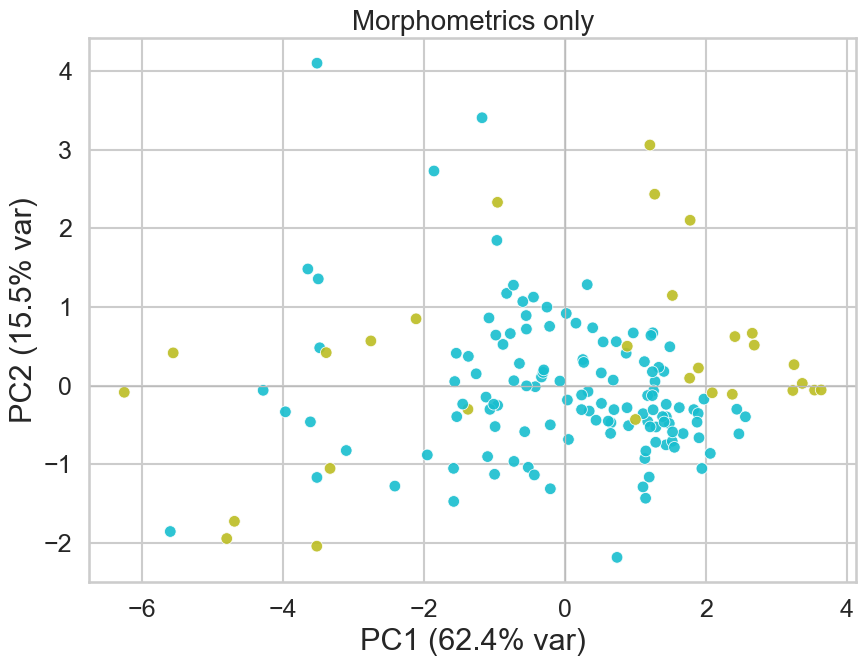

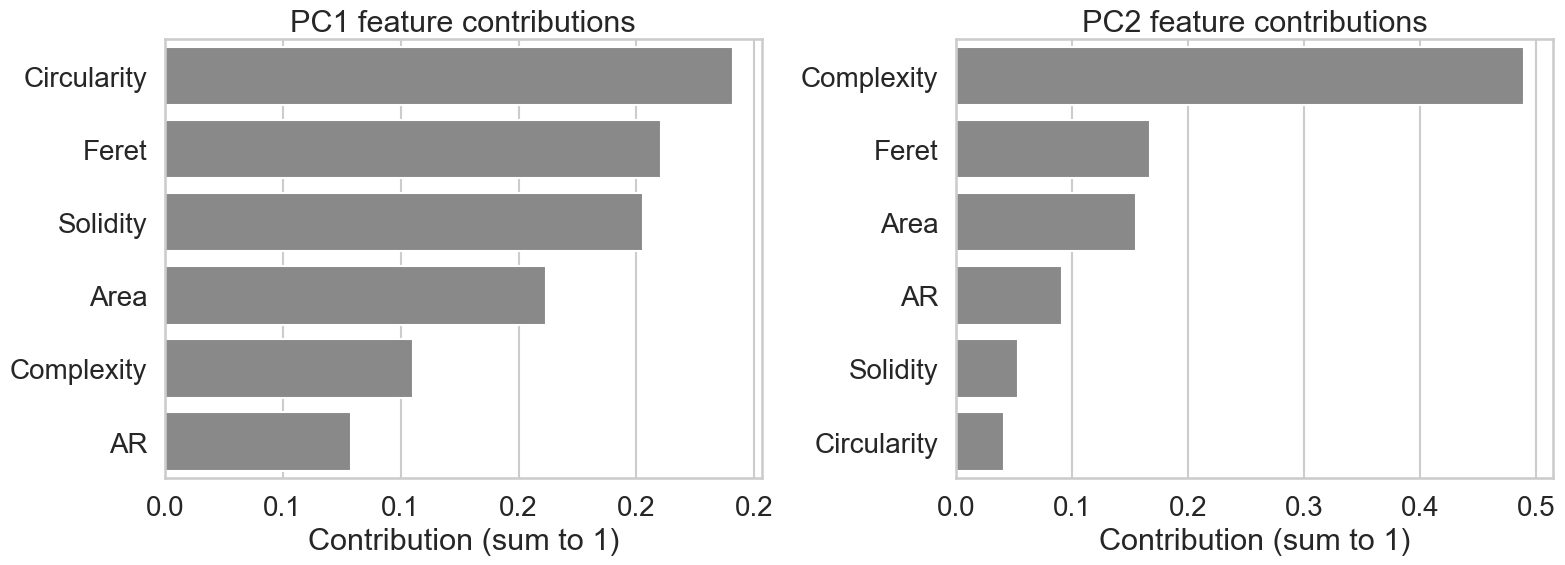

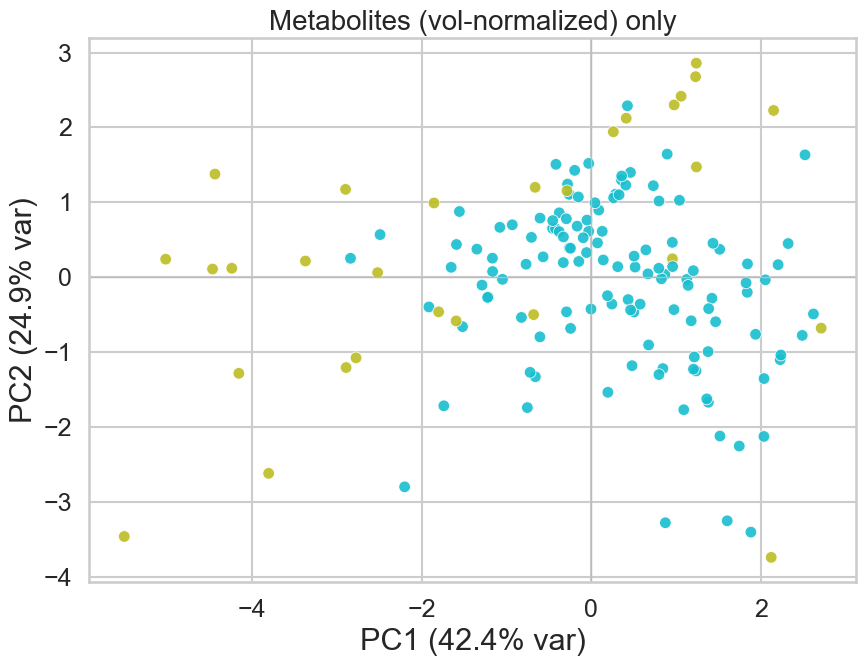

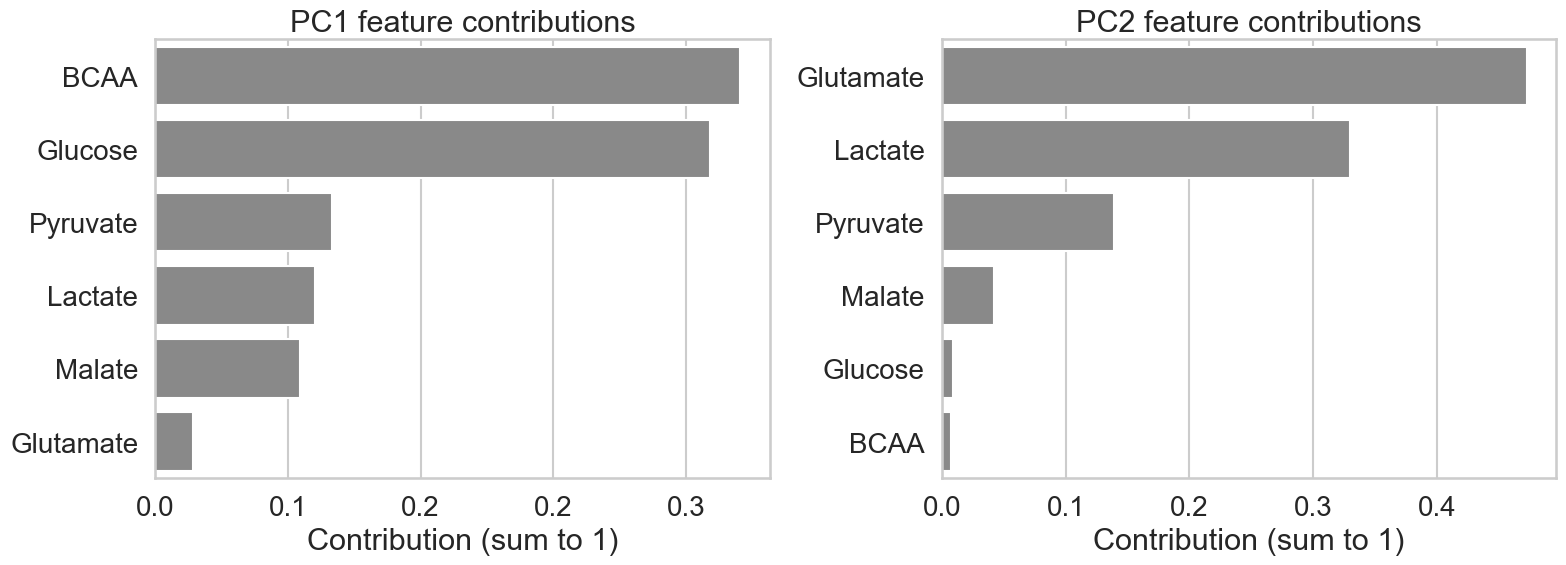

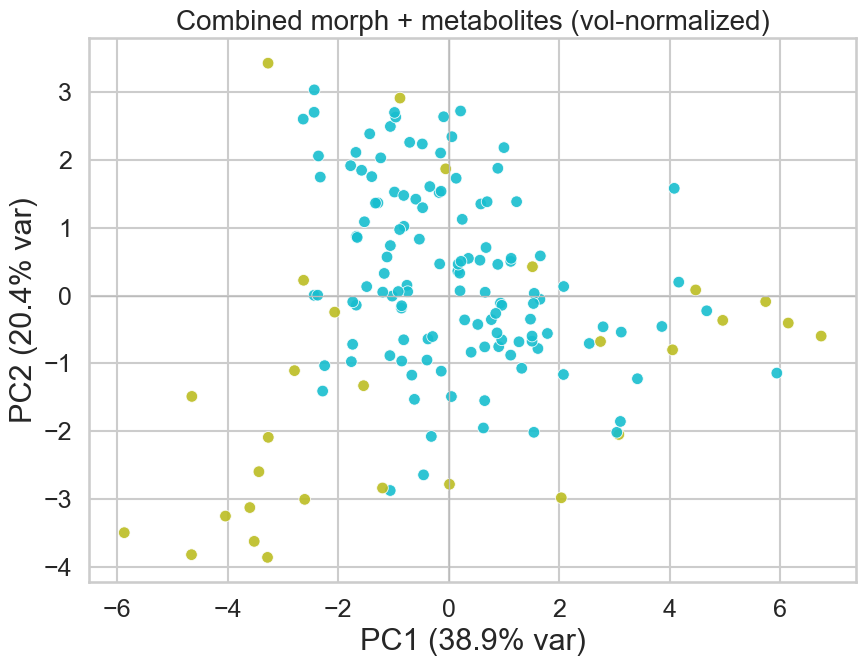

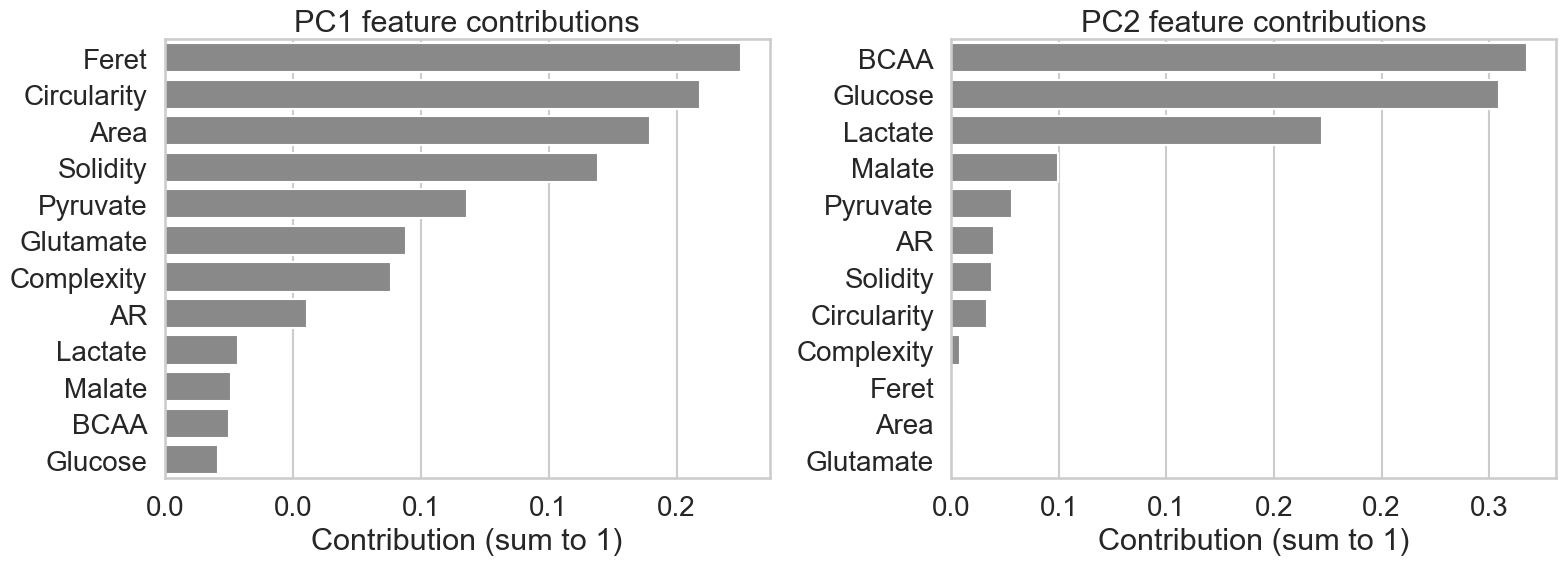

Morphometrics only
Plotted organoids: 155 | Good 126 | Bad 29
Explained variance ratio PC1/PC2: [0.624  0.1547]
Silhouette score on PCA space: 0.2685
   index Classification      mean    median       min       max
0      0            Bad -0.173987 -0.126306 -0.473136 -0.044400
1      1           Good  0.370383  0.398722  0.040004  0.502063
                PC1_loading  PC1_contrib
Circ._win          0.491024     0.241105
Feret_win         -0.458715     0.210419
Solidity_win       0.450256     0.202731
Area_win          -0.402022     0.161622
Complexity_win    -0.324163     0.105081
AR_win            -0.281144     0.079042
                PC2_loading  PC2_contrib
Complexity_win     0.700208     0.490291
Feret_win         -0.409122     0.167381
Area_win          -0.394256     0.155437
AR_win            -0.302929     0.091766
Solidity_win      -0.231006     0.053364
Circ._win         -0.204356     0.041761
Metabolites (vol-normalized) only
Plotted organoids: 155 | Good 126 | Bad 29
Explain

In [34]:
#PCA plots for Morph, Metab and both (HQ vs LQ) - only day 30 (Figs. 3A, 3B; 4A, 4B; 6A, 6B)

feature_rename_dict = {
    'Area_win': 'Area',
    'Circ._win': 'Circularity',
    'Feret_win': 'Feret',
    'Complexity_win': 'Complexity',
    'Solidity_win': 'Solidity',
    'AR_win': 'AR',
    'BCAAGlo_win_vol_norm': 'BCAA',
    'GlutamateGlo_win_vol_norm': 'Glutamate',
    'GlucoseGlo_win_vol_norm': 'Glucose',
    'LactateGlo_win_vol_norm': 'Lactate',
    'PyruvateGlo_win_vol_norm': 'Pyruvate',
    'MalateGlo_win_vol_norm': 'Malate',
}

sns.set_context('talk')

# Day 30 Good vs Bad
pca_df30 = df_sub.copy()
pca_df30['Day'] = pd.to_numeric(pca_df30['Day'], errors='coerce')
pca_df30 = pca_df30[(pca_df30['Day'] == 30) & (pca_df30['Classification'].isin(['Good', 'Bad']))].copy()

pca_base_cols = ['Organoid', 'Classification']
pca_morph_cols = [c for c in morph_cols_win if c in pca_df30.columns]
pca_metab_cols = [c for c in metab_cols_win_vol_norm if c in pca_df30.columns]


def pca_plot_no_arrows(case_name, feature_cols, fig_name, bar_top_n=15):
    if len(feature_cols) == 0:
        print(case_name + ' skipped: no features present on day 30')
        return None

    work_df = pca_df30[pca_base_cols + feature_cols].copy()
    work_df = work_df.dropna(subset=feature_cols)
    work_df = work_df.groupby(pca_base_cols, as_index=False)[feature_cols].mean()

    class_counts = work_df['Classification'].value_counts().to_dict()
    n_good = int(class_counts.get('Good', 0))
    n_bad = int(class_counts.get('Bad', 0))

    if n_good < 2 or n_bad < 2:
        print(case_name + ' skipped: insufficient class counts after dropping NA. Good ' + str(n_good) + ' Bad ' + str(n_bad))
        return None

    X = work_df[feature_cols].values
    y = work_df['Classification'].values

    Xs = StandardScaler().fit_transform(X)
    pca = PCA(n_components=2, random_state=0)
    PCs = pca.fit_transform(Xs)
    evr = pca.explained_variance_ratio_

    # Silhouette on PCA space
    y_num = pd.Series(y).map({'Good': 0, 'Bad': 1}).values
    y_num = pd.Series(y).map({'Good': 0, 'Bad': 1}).values
    sil_score = silhouette_score(PCs, y_num)
    sil_each = silhouette_samples(PCs, y_num)

    loadings = pd.DataFrame(pca.components_.T, index=feature_cols, columns=['PC1', 'PC2'])
    contrib = loadings.pow(2)
    contrib['PC1_contrib'] = contrib['PC1'] / contrib['PC1'].sum()
    contrib['PC2_contrib'] = contrib['PC2'] / contrib['PC2'].sum()
    contrib_tab = contrib[['PC1_contrib', 'PC2_contrib']].copy()

    plot_df = pd.DataFrame({
        'PC1': PCs[:, 0],
        'PC2': PCs[:, 1],
        'Classification': y,
        'Silhouette': sil_each
    })

    plt.figure(figsize=(9, 7))
    ax = sns.scatterplot(
        data=plot_df, x='PC1', y='PC2', hue='Classification',
        palette=classif_colors, s=70, edgecolor='white', linewidth=0.6, alpha=0.9, legend=False
    )
    plt.axhline(0, color='#BBBBBB', lw=1)
    plt.axvline(0, color='#BBBBBB', lw=1)
    plt.xlabel('PC1 (' + str(np.round(evr[0] * 100, 1)) + '% var)', fontsize=22)
    plt.ylabel('PC2 (' + str(np.round(evr[1] * 100, 1)) + '% var)', fontsize=22)
    plt.title(case_name, fontsize=20)
    ax.tick_params(axis='both', labelsize=18)

    plt.tight_layout()
    plt.savefig('./' + fig_name + 'A.png', dpi=220, bbox_inches='tight')
    plt.show()

    top_pc1 = contrib_tab.sort_values('PC1_contrib', ascending=False).head(bar_top_n)
    top_pc2 = contrib_tab.sort_values('PC2_contrib', ascending=False).head(bar_top_n)

    labels_pc1 = [feature_rename_dict.get(name, name) for name in top_pc1.index]
    labels_pc2 = [feature_rename_dict.get(name, name) for name in top_pc2.index]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.barplot(x=top_pc1['PC1_contrib'].values, y=labels_pc1, ax=axes[0], color='#898989')
    axes[0].set_title('PC1 feature contributions', fontsize=22)
    axes[0].set_xlabel('Contribution (sum to 1)', fontsize=22)
    axes[0].set_ylabel('')
    axes[0].xaxis.set_major_locator(mticker.MaxNLocator(6))
    axes[0].xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
    axes[0].tick_params(axis='both', labelsize=20)

    sns.barplot(x=top_pc2['PC2_contrib'].values, y=labels_pc2, ax=axes[1], color='#898989')
    axes[1].set_title('PC2 feature contributions', fontsize=22)
    axes[1].set_xlabel('Contribution (sum to 1)', fontsize=22)
    axes[1].set_ylabel('')
    axes[1].xaxis.set_major_locator(mticker.MaxNLocator(6))
    axes[1].xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
    axes[1].tick_params(axis='both', labelsize=20)

    plt.tight_layout()
    plt.savefig('./' + fig_name + 'B.png', dpi=220, bbox_inches='tight')
    plt.show()

    pc1_tbl = contrib_tab.sort_values('PC1_contrib', ascending=False).copy()
    pc2_tbl = contrib_tab.sort_values('PC2_contrib', ascending=False).copy()
    pc1_tbl['PC1_loading'] = loadings['PC1']
    pc2_tbl['PC2_loading'] = loadings['PC2']
    pc1_tbl = pc1_tbl[['PC1_loading', 'PC1_contrib']].sort_values('PC1_contrib', ascending=False)
    pc2_tbl = pc2_tbl[['PC2_loading', 'PC2_contrib']].sort_values('PC2_contrib', ascending=False)

    sil_tbl = plot_df.groupby('Classification', as_index=False)['Silhouette'].agg(['mean', 'median', 'min', 'max']).reset_index()

    return {
        'case_name': case_name,
        'n_total': int(len(plot_df)),
        'n_good': n_good,
        'n_bad': n_bad,
        'explained_var_ratio': evr,
        'silhouette_score': sil_score,
        'silhouette_table': sil_tbl,
        'pc1_table': pc1_tbl,
        'pc2_table': pc2_tbl
    }


pca_res_morph = pca_plot_no_arrows('Morphometrics only', pca_morph_cols, 'Fig 3')
pca_res_metab = pca_plot_no_arrows('Metabolites (vol-normalized) only', pca_metab_cols, 'Fig 4')
pca_res_combo = pca_plot_no_arrows('Combined morph + metabolites (vol-normalized)', pca_morph_cols + pca_metab_cols, 'Fig 6')

# Print the same compact driver tables as before (top 12 each)
for pca_res in [pca_res_morph, pca_res_metab, pca_res_combo]:
    if pca_res is None:
        continue
    print(pca_res['case_name'])
    print('Plotted organoids: ' + str(pca_res['n_total']) + ' | Good ' + str(pca_res['n_good']) + ' | Bad ' + str(pca_res['n_bad']))
    print('Explained variance ratio PC1/PC2: ' + str(np.round(pca_res['explained_var_ratio'][:2], 4)))
    print('Silhouette score on PCA space: ' + str(np.round(pca_res['silhouette_score'], 4)))
    print(pca_res['silhouette_table'])
    print(pca_res['pc1_table'].head(12))
    print(pca_res['pc2_table'].head(12))

In [19]:
# Setup #1: define feature groups and all combinations with only morph or only metab

morph_feats = ['Area_win_log', 'Feret_win', 'Circ._win', 'Solidity_win', 'AR_win', 'Complexity_win']
metab_feats = ['GlucoseGlo_win_vol_norm', 'GlutamateGlo_win_vol_norm', 'LactateGlo_win_vol_norm',
               'PyruvateGlo_win_vol_norm', 'MalateGlo_win_vol_norm', 'BCAAGlo_win_vol_norm']
all_feats = morph_feats + metab_feats

# Build all feature sets
feature_sets = []

# 1) All 12 together
feature_sets.append(('all-12', all_feats))

# 2) Morphometric combos with >= 2 features
for r in range(2, len(morph_feats)+1):
    for combo in combinations(morph_feats, r):
        short_names = [feat.split('_')[0] for feat in combo]
        feature_sets.append(('Morph-' + '_'.join(short_names), list(combo)))

# 3) Metabolite combos with >= 2 features
for r in range(2, len(metab_feats)+1):
    for combo in combinations(metab_feats, r):
        short_names = [feat.split('_')[0] for feat in combo]
        feature_sets.append(('Metab-' + '_'.join(short_names), list(combo)))

print("Total feature sets: " + str(len(feature_sets)))
print("Names first 5:", [fs[0] for fs in feature_sets[:5]])
print("Feats first 5:", [fs[1] for fs in feature_sets[:5]])

Total feature sets: 115
Names first 5: ['all-12', 'Morph-Area_Feret', 'Morph-Area_Circ.', 'Morph-Area_Solidity', 'Morph-Area_AR']
Feats first 5: [['Area_win_log', 'Feret_win', 'Circ._win', 'Solidity_win', 'AR_win', 'Complexity_win', 'GlucoseGlo_win_vol_norm', 'GlutamateGlo_win_vol_norm', 'LactateGlo_win_vol_norm', 'PyruvateGlo_win_vol_norm', 'MalateGlo_win_vol_norm', 'BCAAGlo_win_vol_norm'], ['Area_win_log', 'Feret_win'], ['Area_win_log', 'Circ._win'], ['Area_win_log', 'Solidity_win'], ['Area_win_log', 'AR_win']]


In [20]:
# Run logistic regression for all days x all feature sets (morph only and metab only), collect results
target_days = [30, 28, 24, 21, 17, 15, 13, 10, 8, 6, 3]
seeds = [20, 17, 75, 27, 33]
bal_thr = 0.5

combo_results = []

for d in tqdm(target_days, desc='Days'):
    combo_df = df_sub[pd.to_numeric(df_sub['Day'], errors='coerce') == d].copy()
    if combo_df.empty:
        continue

    for fs_name, fs_cols in tqdm(feature_sets, desc='Feature sets day ' + str(d), leave=False):
        # Only keep cols that exist in df
        valid_cols = [c for c in fs_cols if c in combo_df.columns]
        if len(valid_cols) < 2:
            continue

        # Aggregate per organoid
        agg = combo_df.groupby(['Organoid', 'Classification'], as_index=False)[valid_cols].mean()
        agg = agg[agg['Classification'].isin(['Good', 'Bad'])].dropna(subset=valid_cols)

        if agg['Classification'].nunique() < 2 or agg.shape[0] < 5:
            continue

        X = agg[valid_cols].values
        y = (agg['Classification'] == 'Good').astype(int).values

        f1_list = []
        ba_list = []
        cm_list = []
        auc_list = []

        for rs in seeds:
            try:
                X_train, X_test, y_train, y_test = train_test_split(
                    X, y, test_size=0.30, random_state=rs, stratify=y)
                pipe = Pipeline([
                    ('scaler', StandardScaler()),
                    ('lr', LogisticRegression(max_iter=2000, class_weight='balanced', solver='liblinear'))
                ])
                pipe.fit(X_train, y_train)
                p_test = pipe.predict_proba(X_test)[:, 1]
                yhat = (p_test >= bal_thr).astype(int)

                f1 = f1_score(y_test, yhat, zero_division=0)
                ba = balanced_accuracy_score(y_test, yhat)
                cm = confusion_matrix(y_test, yhat)
                fpr, tpr, _ = roc_curve(y_test, p_test)
                roc_auc = auc(fpr, tpr)

                f1_list.append(f1)
                ba_list.append(ba)
                cm_list.append(cm)
                auc_list.append(roc_auc)
            except Exception:
                f1_list.append(np.nan)
                ba_list.append(np.nan)
                cm_list.append(None)
                auc_list.append(np.nan)

        # Median seed index for balanced accuracy
        valid_ba = [(i, v) for i, v in enumerate(ba_list) if not np.isnan(v)]
        if not valid_ba:
            continue
        sorted_ba_idx = sorted(valid_ba, key=lambda x: x[1])
        med_idx = sorted_ba_idx[len(sorted_ba_idx) // 2][0]
        cm_med = cm_list[med_idx]

        tn, fp, fn, tp = (cm_med.ravel() if cm_med is not None and cm_med.size == 4 else (np.nan,)*4)

        row = {
            'Day': d,
            'FeatureSet': fs_name,
            'Features': ';'.join(valid_cols),
            'N_features': len(valid_cols),
            'F1_mean': np.nanmean(f1_list),
            'F1_median': np.nanmedian(f1_list),
            'BA_mean': np.nanmean(ba_list),
            'BA_median': np.nanmedian(ba_list),
            'AUC_mean': np.nanmean(auc_list),
            'AUC_median': np.nanmedian(auc_list)
        }
        for i, rs in enumerate(seeds):
            row['F1_seed_' + str(rs)] = f1_list[i]
            row['BA_seed_' + str(rs)] = ba_list[i]

        row['CM_median_TN'] = tn
        row['CM_median_FP'] = fp
        row['CM_median_FN'] = fn
        row['CM_median_TP'] = tp

        combo_results.append(row)

Days: 100%|██████████| 11/11 [00:44<00:00,  4.07s/it]                


In [21]:
# Setup #2: define feature groups and combinations (Base Morph + All Metab)

base_morph_sets = [
    ['Area_win_log', 'Feret_win'],
    ['Area_win_log', 'Circ._win'],
    ['Area_win_log', 'AR_win'],
    ['Complexity_win', 'Solidity_win'],
    ['Feret_win', 'Solidity_win'],
    ['Feret_win', 'Circ._win'],
    ['Area_win_log', 'Feret_win', 'Circ._win'],
    ['Area_win_log', 'Feret_win', 'AR_win'],
    ['Area_win_log', 'Feret_win', 'Complexity_win'],
    ['Area_win_log', 'AR_win', 'Solidity_win'],
    ['Complexity_win', 'Solidity_win', 'Circ._win'],
    ['Feret_win', 'Solidity_win', 'Complexity_win'],
    ['Feret_win', 'Circ._win', 'Solidity_win']
]

metab_nonempty = []
for r in range(1, len(metab_feats) + 1):
    for combo_mt_vals in combinations(metab_feats, r):
        metab_nonempty.append(list(combo_mt_vals))

bmp_feature_sets = []
for base_bmp_feats in base_morph_sets:
    bmp_short_names = [feat.split('_')[0] for feat in base_bmp_feats]
    base_bmp_name = 'MorphBase-' + '_'.join(bmp_short_names)
    for metab_vals in metab_nonempty:
        combo_bmp_feats = base_bmp_feats + metab_vals
        metab_short_names = [feat.split('_')[0] for feat in metab_vals]
        combo_bmp_name = base_bmp_name + '+Metab-' + '_'.join(metab_short_names)
        bmp_feature_sets.append((combo_bmp_name, list(combo_bmp_feats)))

print('Base morph sets: ', len(base_morph_sets))
print('Metab nonempty combos: ', len(metab_nonempty))
print('All feature sets: ', len(bmp_feature_sets))
print("Names first 3:", [fs[0] for fs in bmp_feature_sets[:3]])
print("Feats first 3:", [fs[1] for fs in bmp_feature_sets[:3]])

Base morph sets:  13
Metab nonempty combos:  63
All feature sets:  819
Names first 3: ['MorphBase-Area_Feret+Metab-GlucoseGlo', 'MorphBase-Area_Feret+Metab-GlutamateGlo', 'MorphBase-Area_Feret+Metab-LactateGlo']
Feats first 3: [['Area_win_log', 'Feret_win', 'GlucoseGlo_win_vol_norm'], ['Area_win_log', 'Feret_win', 'GlutamateGlo_win_vol_norm'], ['Area_win_log', 'Feret_win', 'LactateGlo_win_vol_norm']]


In [22]:
# Run logistic regression for all days x all feature sets (Base Moprh + All Metab), collect results

for d in tqdm(target_days, desc='Days'):
    combo_df = df_sub[pd.to_numeric(df_sub['Day'], errors='coerce') == d].copy()
    if combo_df.empty:
        continue
    for bmp_fs_name, bmp_fs_cols in tqdm(bmp_feature_sets, desc='Feature sets day ' + str(d), leave=False):
        # Only keep cols that exist in df
        bmp_valid_cols = [c for c in bmp_fs_cols if c in combo_df.columns]
        if len(bmp_valid_cols) < 2:
            continue
        
        # Aggregate per organoid
        bmp_agg = combo_df.groupby(['Organoid', 'Classification'], as_index=False)[bmp_valid_cols].mean()
        bmp_agg = bmp_agg[bmp_agg['Classification'].isin(['Good', 'Bad'])].dropna(subset=bmp_valid_cols)

        if bmp_agg['Classification'].nunique() < 2 or bmp_agg.shape[0] < 5:
            continue

        X = bmp_agg[bmp_valid_cols].values
        y = (bmp_agg['Classification'] == 'Good').astype(int).values

        f1_list = []
        ba_list = []
        cm_list = []
        auc_list = []

        for rs in seeds:
            try:
                X_train, X_test, y_train, y_test = train_test_split(
                    X, y, test_size=0.30, random_state=rs, stratify=y)
                pipe = Pipeline([
                    ('scaler', StandardScaler()),
                    ('lr', LogisticRegression(max_iter=2000, class_weight='balanced', solver='liblinear'))
                ])
                pipe.fit(X_train, y_train)
                p_test = pipe.predict_proba(X_test)[:, 1]
                yhat = (p_test >= bal_thr).astype(int)

                f1 = f1_score(y_test, yhat, zero_division=0)
                ba = balanced_accuracy_score(y_test, yhat)
                cm = confusion_matrix(y_test, yhat)
                fpr, tpr, _ = roc_curve(y_test, p_test)
                roc_auc = auc(fpr, tpr)

                f1_list.append(f1)
                ba_list.append(ba)
                cm_list.append(cm)
                auc_list.append(roc_auc)
            except Exception:
                f1_list.append(np.nan)
                ba_list.append(np.nan)
                cm_list.append(None)
                auc_list.append(np.nan)

        # Median seed index for balanced accuracy
        valid_ba = [(i, v) for i, v in enumerate(ba_list) if not np.isnan(v)]
        if not valid_ba:
            continue
        sorted_ba_idx = sorted(valid_ba, key=lambda x: x[1])
        med_idx = sorted_ba_idx[len(sorted_ba_idx) // 2][0]
        cm_med = cm_list[med_idx]

        tn, fp, fn, tp = (cm_med.ravel() if cm_med is not None and cm_med.size == 4 else (np.nan,)*4)

        row = {
            'Day': d,
            'FeatureSet': bmp_fs_name,
            'Features': ';'.join(bmp_valid_cols),
            'N_features': len(bmp_valid_cols),
            'F1_mean': np.nanmean(f1_list),
            'F1_median': np.nanmedian(f1_list),
            'BA_mean': np.nanmean(ba_list),
            'BA_median': np.nanmedian(ba_list),
            'AUC_mean': np.nanmean(auc_list),
            'AUC_median': np.nanmedian(auc_list)
        }
        for i, rs in enumerate(seeds):
            row['F1_seed_' + str(rs)] = f1_list[i]
            row['BA_seed_' + str(rs)] = ba_list[i]

        row['CM_median_TN'] = tn
        row['CM_median_FP'] = fp
        row['CM_median_FN'] = fn
        row['CM_median_TP'] = tp

        combo_results.append(row)

Days: 100%|██████████| 11/11 [05:19<00:00, 29.02s/it]                


In [23]:
# Setup #3: define feature groups and combinations (Base Metab + All Morph)

base_metab_sets = [
    ['MalateGlo_win_vol_norm', 'LactateGlo_win_vol_norm'],
    ['LactateGlo_win_vol_norm', 'GlucoseGlo_win_vol_norm'],
    ['BCAAGlo_win_vol_norm', 'PyruvateGlo_win_vol_norm'],
    ['MalateGlo_win_vol_norm', 'GlucoseGlo_win_vol_norm'],
    ['MalateGlo_win_vol_norm', 'GlutamateGlo_win_vol_norm'],
    ['GlutamateGlo_win_vol_norm', 'PyruvateGlo_win_vol_norm'],
    ['GlutamateGlo_win_vol_norm', 'BCAAGlo_win_vol_norm'],
    ['LactateGlo_win_vol_norm', 'GlutamateGlo_win_vol_norm'],
    ['GlutamateGlo_win_vol_norm', 'GlucoseGlo_win_vol_norm'],
    ['PyruvateGlo_win_vol_norm', 'GlucoseGlo_win_vol_norm'],
    ['MalateGlo_win_vol_norm', 'LactateGlo_win_vol_norm', 'GlucoseGlo_win_vol_norm'],
    ['BCAAGlo_win_vol_norm', 'PyruvateGlo_win_vol_norm', 'GlucoseGlo_win_vol_norm'],
    ['MalateGlo_win_vol_norm', 'GlucoseGlo_win_vol_norm', 'PyruvateGlo_win_vol_norm'], ['GlutamateGlo_win_vol_norm', 'PyruvateGlo_win_vol_norm', 'BCAAGlo_win_vol_norm'], ['GlutamateGlo_win_vol_norm', 'BCAAGlo_win_vol_norm', 'MalateGlo_win_vol_norm'], ['LactateGlo_win_vol_norm', 'GlutamateGlo_win_vol_norm', 'GlucoseGlo_win_vol_norm'], ['GlutamateGlo_win_vol_norm', 'GlucoseGlo_win_vol_norm', 'BCAAGlo_win_vol_norm'], ['PyruvateGlo_win_vol_norm', 'GlucoseGlo_win_vol_norm', 'GlutamateGlo_win_vol_norm']
]

morph_nonempty = []
for r in range(1, len(morph_feats) + 1):
    for combo_mp_vals in combinations(morph_feats, r):
        morph_nonempty.append(list(combo_mp_vals))

bmt_feature_sets = []
for base_bmt_feats in base_metab_sets:
    bmt_short_names = [feat.split('_')[0] for feat in base_bmt_feats]
    base_bmt_name = 'MetabBase-' + '_'.join(bmt_short_names)
    for morph_vals in morph_nonempty:
        combo_bmt_feats = base_bmt_feats + morph_vals
        morph_short_names = [feat.split('_')[0] for feat in morph_vals]
        combo_bmt_name = base_bmt_name + '+Morph-' + '_'.join(morph_short_names)
        bmt_feature_sets.append((combo_bmt_name, list(combo_bmt_feats)))

print('Base metab sets: ',len(base_metab_sets))
print('Moprh nonempty combos: ', len(morph_nonempty))
print('Base Metab feature sets: ', len(bmt_feature_sets))
print("Names first 3:", [fs[0] for fs in bmt_feature_sets[:3]])
print("Feats first 3:", [fs[1] for fs in bmt_feature_sets[:3]])

Base metab sets:  18
Moprh nonempty combos:  63
Base Metab feature sets:  1134
Names first 3: ['MetabBase-MalateGlo_LactateGlo+Morph-Area', 'MetabBase-MalateGlo_LactateGlo+Morph-Feret', 'MetabBase-MalateGlo_LactateGlo+Morph-Circ.']
Feats first 3: [['MalateGlo_win_vol_norm', 'LactateGlo_win_vol_norm', 'Area_win_log'], ['MalateGlo_win_vol_norm', 'LactateGlo_win_vol_norm', 'Feret_win'], ['MalateGlo_win_vol_norm', 'LactateGlo_win_vol_norm', 'Circ._win']]


In [24]:
# Run logistic regression for all days x all feature sets (Base Moprh + All Metab), collect results
combo_results_add = []

for d in tqdm(target_days, desc='Days'):
    combo_df = df_sub[pd.to_numeric(df_sub['Day'], errors='coerce') == d].copy()
    if combo_df.empty:
        continue
    for bmt_fs_name, bmt_fs_cols in tqdm(bmt_feature_sets, desc='Feature sets day ' + str(d), leave=False):
        # Only keep cols that exist in df
        bmt_valid_cols = [c for c in bmt_fs_cols if c in combo_df.columns]
        if len(bmt_valid_cols) < 2:
            continue

        # Aggregate per organoid
        bmt_agg = combo_df.groupby(['Organoid', 'Classification'], as_index=False)[bmt_valid_cols].mean()
        bmt_agg = bmt_agg[bmt_agg['Classification'].isin(['Good', 'Bad'])].dropna(subset=bmt_valid_cols)

        if bmt_agg['Classification'].nunique() < 2 or bmt_agg.shape[0] < 5:
            continue

        X = bmt_agg[bmt_valid_cols].values
        y = (bmt_agg['Classification'] == 'Good').astype(int).values


        f1_list = []
        ba_list = []
        cm_list = []
        auc_list = []
        
        for rs in seeds:
            try:
                X_train, X_test, y_train, y_test = train_test_split(
                    X, y, test_size=0.30, random_state=rs, stratify=y)
                pipe = Pipeline([
                    ('scaler', StandardScaler()),
                    ('lr', LogisticRegression(max_iter=2000, class_weight='balanced', solver='liblinear'))
                ])
                pipe.fit(X_train, y_train)
                p_test = pipe.predict_proba(X_test)[:, 1]
                yhat = (p_test >= bal_thr).astype(int)

                f1 = f1_score(y_test, yhat, zero_division=0)
                ba = balanced_accuracy_score(y_test, yhat)
                cm = confusion_matrix(y_test, yhat)
                fpr, tpr, _ = roc_curve(y_test, p_test)
                roc_auc = auc(fpr, tpr)

                f1_list.append(f1)
                ba_list.append(ba)
                cm_list.append(cm)
                auc_list.append(roc_auc)
            except Exception:
                f1_list.append(np.nan)
                ba_list.append(np.nan)
                cm_list.append(None)
                auc_list.append(np.nan)

        # Median seed index for balanced accuracy
        valid_ba = [(i, v) for i, v in enumerate(ba_list) if not np.isnan(v)]
        if not valid_ba:
            continue
        sorted_ba_idx = sorted(valid_ba, key=lambda x: x[1])
        med_idx = sorted_ba_idx[len(sorted_ba_idx) // 2][0]
        cm_med = cm_list[med_idx]

        tn, fp, fn, tp = (cm_med.ravel() if cm_med is not None and cm_med.size == 4 else (np.nan,)*4)

        row = {
            'Day': d,
            'FeatureSet': bmt_fs_name,
            'Features': ';'.join(bmt_valid_cols),
            'N_features': len(bmt_valid_cols),
            'F1_mean': np.nanmean(f1_list),
            'F1_median': np.nanmedian(f1_list),
            'BA_mean': np.nanmean(ba_list),
            'BA_median': np.nanmedian(ba_list),
            'AUC_mean': np.nanmean(auc_list),
            'AUC_median': np.nanmedian(auc_list)
        }
        for i, rs in enumerate(seeds):
            row['F1_seed_' + str(rs)] = f1_list[i]
            row['BA_seed_' + str(rs)] = ba_list[i]

        row['CM_median_TN'] = tn
        row['CM_median_FP'] = fp
        row['CM_median_FN'] = fn
        row['CM_median_TP'] = tp

        combo_results_add.append(row)

Days: 100%|██████████| 11/11 [07:18<00:00, 39.91s/it]                  


In [25]:
# Save results to CSV
all_combo_results = combo_results + combo_results_add
combo_df_results = pd.DataFrame(all_combo_results)
print("Total rows: " + str(len(combo_df_results)))
print(combo_df_results.head())

output_path = 'logistic_regression_results_all_days_featuresets.csv'
combo_df_results.to_csv(output_path, index=False)
print("Saved to: " + output_path)
print("Shape: " + str(combo_df_results.shape))

Total rows: 22748
   Day           FeatureSet  \
0   30               all-12   
1   30     Morph-Area_Feret   
2   30     Morph-Area_Circ.   
3   30  Morph-Area_Solidity   
4   30        Morph-Area_AR   

                                            Features  N_features   F1_mean  \
0  Area_win_log;Feret_win;Circ._win;Solidity_win;...          12  0.890836   
1                             Area_win_log;Feret_win           2  0.871632   
2                             Area_win_log;Circ._win           2  0.815333   
3                          Area_win_log;Solidity_win           2  0.810447   
4                                Area_win_log;AR_win           2  0.798150   

   F1_median   BA_mean  BA_median  AUC_mean  AUC_median  ...  F1_seed_75  \
0   0.885714  0.784503   0.780702  0.802924    0.839181  ...    0.868421   
1   0.869565  0.841813   0.836257  0.923392    0.953216  ...    0.852941   
2   0.835821  0.752047   0.770468  0.805263    0.792398  ...    0.852941   
3   0.818182  0.757895

In [19]:
# Get top 10 combos by BA_mean on day 30
lr_csv_file = 'logistic_regression_results_all_days_featuresets.csv'
combo_df_results = pd.read_csv(lr_csv_file)
full_results = combo_df_results
top10_day30 = (
    full_results[full_results['Day'] == 30]
    .assign(
        Features_norm=lambda df: df['Features'].apply(
            lambda x: ';'.join(sorted(set(
                feat.strip() for feat in str(x).split(';') if feat.strip() != ''
            )))
        )
    )
    .sort_values('BA_mean', ascending=False)
    .drop_duplicates(subset='Features_norm', keep='first')
    .head(10)
    .reset_index(drop=True)
)

print(top10_day30[['Features', 'BA_mean']])

                                            Features   BA_mean
0  Area_win_log;Feret_win;AR_win;GlutamateGlo_win...  0.935088
1  GlutamateGlo_win_vol_norm;PyruvateGlo_win_vol_...  0.932456
2  GlutamateGlo_win_vol_norm;PyruvateGlo_win_vol_...  0.924561
3  GlutamateGlo_win_vol_norm;PyruvateGlo_win_vol_...  0.924561
4  GlutamateGlo_win_vol_norm;PyruvateGlo_win_vol_...  0.921930
5  GlutamateGlo_win_vol_norm;PyruvateGlo_win_vol_...  0.921930
6  GlutamateGlo_win_vol_norm;PyruvateGlo_win_vol_...  0.921930
7  GlutamateGlo_win_vol_norm;PyruvateGlo_win_vol_...  0.921930
8  GlutamateGlo_win_vol_norm;PyruvateGlo_win_vol_...  0.921930
9  GlutamateGlo_win_vol_norm;PyruvateGlo_win_vol_...  0.919298


In [20]:
# For each of the 10 combos, get BA_mean for every day from the full results
day_order = [3, 6, 8, 10, 13, 15, 17, 21, 24, 28, 30]
top10_features = top10_day30['Features'].tolist()

# Build a lookup: Features -> Day -> BA_mean
ba_lookup = full_results.set_index(['Features', 'Day'])['BA_mean']

rows = []
for feat_str in top10_features:
    row = {'Features': feat_str}
    for day_val in day_order:
        try:
            row['Day_' + str(day_val)] = ba_lookup.loc[(feat_str, day_val)]
        except KeyError:
            row['Day_' + str(day_val)] = np.nan
    rows.append(row)

top10_day30_alldays = pd.DataFrame(rows)
print(top10_day30_alldays[['Features'] + ['Day_' + str(d) for d in day_order]])

                                            Features     Day_3     Day_6  \
0  Area_win_log;Feret_win;AR_win;GlutamateGlo_win...  0.649882  0.650444   
1  GlutamateGlo_win_vol_norm;PyruvateGlo_win_vol_...  0.565721  0.654444   
2  GlutamateGlo_win_vol_norm;PyruvateGlo_win_vol_...  0.570449  0.669556   
3  GlutamateGlo_win_vol_norm;PyruvateGlo_win_vol_...  0.617021  0.689778   
4  GlutamateGlo_win_vol_norm;PyruvateGlo_win_vol_...  0.548700  0.661556   
5  GlutamateGlo_win_vol_norm;PyruvateGlo_win_vol_...  0.585816  0.635111   
6  GlutamateGlo_win_vol_norm;PyruvateGlo_win_vol_...  0.566194  0.665556   
7  GlutamateGlo_win_vol_norm;PyruvateGlo_win_vol_...  0.583688  0.634222   
8  GlutamateGlo_win_vol_norm;PyruvateGlo_win_vol_...  0.559338  0.663556   
9  GlutamateGlo_win_vol_norm;PyruvateGlo_win_vol_...  0.587943  0.633111   

      Day_8    Day_10    Day_13    Day_15    Day_17    Day_21    Day_24  \
0  0.697279  0.604444  0.647333  0.628000  0.505896  0.666071  0.750355   
1  0.735601  

In [21]:
# Build feature presence matrix and rank feature columns by count among top 10 day-30 combos
all_feats = ['Area_win_log', 'Feret_win', 'Circ._win', 'Solidity_win', 'AR_win', 'Complexity_win',
             'GlucoseGlo_win_vol_norm', 'GlutamateGlo_win_vol_norm', 'LactateGlo_win_vol_norm',
             'PyruvateGlo_win_vol_norm', 'MalateGlo_win_vol_norm', 'BCAAGlo_win_vol_norm']

feat_presence = pd.DataFrame(0, index=top10_day30_alldays['Features'], columns=all_feats)
for feat_str in top10_day30_alldays['Features']:
    for feat_name in feat_str.split(';'):
        if feat_name in feat_presence.columns:
            feat_presence.loc[feat_str, feat_name] = 1

feat_counts = feat_presence.sum(axis=0).sort_values(ascending=False)
feat_col_order = feat_counts.index.tolist()
print('Feature column order (by count in top-10 day-30 combos):')
print(feat_counts)

Feature column order (by count in top-10 day-30 combos):
Area_win_log                 10
Feret_win                    10
GlutamateGlo_win_vol_norm    10
PyruvateGlo_win_vol_norm     10
Complexity_win                5
Circ._win                     4
Solidity_win                  4
AR_win                        4
MalateGlo_win_vol_norm        1
GlucoseGlo_win_vol_norm       0
LactateGlo_win_vol_norm       0
BCAAGlo_win_vol_norm          0
dtype: int64


In [22]:
all_12_rows = []
for day_val in day_order:
    try:
        row['Day_' + str(day_val)] = ba_lookup.loc[(';'.join(all_feats), day_val)]
    except KeyError:
        row['Day_' + str(day_val)] = np.nan
all_12_rows.append(row)

all_12_results = pd.DataFrame(all_12_rows)
print(all_12_results[['Features'] + ['Day_' + str(d) for d in day_order]])

                                            Features     Day_3     Day_6  \
0  GlutamateGlo_win_vol_norm;PyruvateGlo_win_vol_...  0.605437  0.670667   

      Day_8    Day_10    Day_13    Day_15    Day_17    Day_21   Day_24  \
0  0.725624  0.643778  0.668222  0.673333  0.649433  0.739286  0.75461   

     Day_28    Day_30  
0  0.778659  0.784503  


In [23]:
# Now load the original heatmap code reference and build the new heatmap
# Row order: all_12 on top, then top-10 day-30 combos ranked by BA_mean on day 30 (descending)
# Column order: features ranked by count in top-10 day-30 combos (descending)

short_label_map = {
    'Area_win_log': 'Area',
    'Circ._win': 'Circularity',
    'Feret_win': 'Feret',
    'Complexity_win': 'Complexity',
    'Solidity_win': 'Solidity',
    'AR_win': 'AR',
    'BCAAGlo_win_vol_norm': 'BCAA',
    'GlutamateGlo_win_vol_norm': 'Glutamate',
    'GlucoseGlo_win_vol_norm': 'Glucose',
    'LactateGlo_win_vol_norm': 'Lactate',
    'PyruvateGlo_win_vol_norm': 'Pyruvate',
    'MalateGlo_win_vol_norm': 'Malate',
}

# Build short row labels
def make_short_label(feat_str):
    parts = feat_str.split(';')
    short_parts = [short_label_map.get(p, p) for p in parts]
    return ' + '.join(short_parts)

# Build BA matrix: rows = all_12 + top10 combos, cols = days
ba_rows = []
row_labels = []

# all_12 row first
ba_rows.append([float(all_12_results['Day_' + str(d)].iloc[0]) for d in day_order])
row_labels.append('All 12')

# top 10 combos sorted by BA_mean on day 30 descending (already sorted)
for _, row_data in top10_day30_alldays.iterrows():
    ba_rows.append([row_data['Day_' + str(d)] for d in day_order])
    row_labels.append(make_short_label(row_data['Features']))

ba_matrix = pd.DataFrame(ba_rows, index=row_labels, columns=['Day ' + str(d) for d in day_order])

# Feature presence matrix: rows = all_12 + top10, cols = features (ordered by count)
pres_rows = []
all12_pres = {f: 1 for f in all_feats}  # all 12 features present
pres_rows.append([all12_pres[f] for f in feat_col_order])
for feat_str in top10_day30_alldays['Features']:
    pres_rows.append([1 if f in feat_str.split(';') else 0 for f in feat_col_order])

feat_short_cols = [short_label_map.get(f, f) for f in feat_col_order]
pres_matrix = pd.DataFrame(pres_rows, index=row_labels, columns=feat_short_cols)

print('BA matrix shape:', ba_matrix.shape)
print('Presence matrix shape:', pres_matrix.shape)
print(ba_matrix.round(3))

BA matrix shape: (11, 11)
Presence matrix shape: (11, 12)
                                                    Day 3  Day 6  Day 8  \
All 12                                              0.605  0.671  0.726   
Area + Feret + AR + Glutamate + Pyruvate + Malate   0.650  0.650  0.697   
Glutamate + Pyruvate + Area + Feret + AR            0.566  0.654  0.736   
Glutamate + Pyruvate + Area + Feret + Circulari...  0.570  0.670  0.684   
Glutamate + Pyruvate + Area + Feret + Circulari...  0.617  0.690  0.689   
Glutamate + Pyruvate + Area + Feret + Solidity ...  0.549  0.662  0.691   
Glutamate + Pyruvate + Area + Feret + Solidity      0.586  0.635  0.682   
Glutamate + Pyruvate + Area + Feret + AR + Comp...  0.566  0.666  0.720   
Glutamate + Pyruvate + Area + Feret + Circulari...  0.584  0.634  0.686   
Glutamate + Pyruvate + Area + Feret                 0.559  0.664  0.735   
Glutamate + Pyruvate + Area + Feret + Circulari...  0.588  0.633  0.684   

                                         

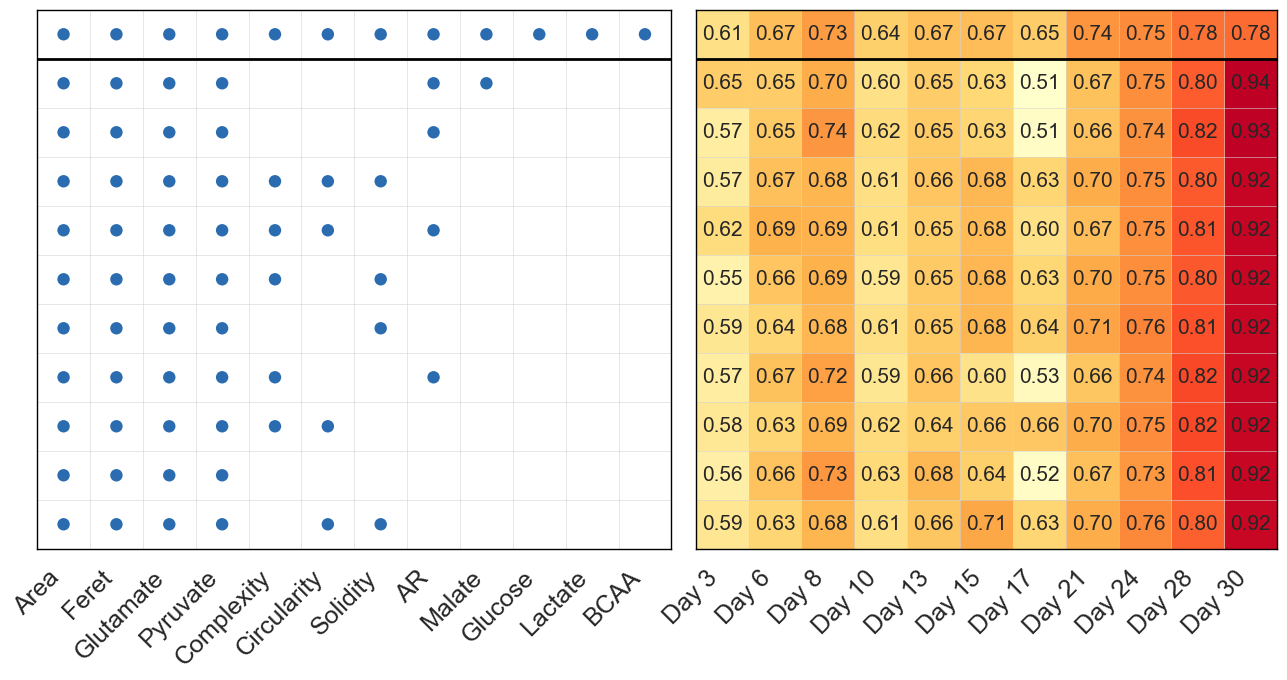

In [24]:
# Feature Combos for Top 10 BA Score (Fig. 6C)

n_rows = len(ba_matrix)
feat_short_cols = pres_matrix.columns.tolist()
row_names = pres_matrix.index.tolist()
feat_vals = pres_matrix.values
ba_vals = ba_matrix.values

fig = plt.figure(figsize=(16, 7))
gs = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[len(feat_short_cols), len(day_order)], wspace=0.04)
ax_feat = fig.add_subplot(gs[0, 0])
ax_ba = fig.add_subplot(gs[0, 1])

ax_feat.grid(False)
ax_ba.grid(False)

for ax in [ax_feat, ax_ba]:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1.0)

# Left panel with circles instead of filled squares
for row_idx in range(n_rows):
    for col_idx in range(len(feat_short_cols)):
        if feat_vals[row_idx, col_idx] == 1:
            ax_feat.scatter(col_idx + 0.5, row_idx + 0.5, s=80, marker='o', color='#2b6cb0', edgecolors='none')
ax_feat.set_xlim(0, len(feat_short_cols))
ax_feat.set_ylim(n_rows, 0)
ax_feat.set_xticks(np.arange(len(feat_short_cols)) + 0.5)
ax_feat.set_xticklabels(feat_short_cols, rotation=45, ha='right', fontsize=18)
ax_feat.set_yticks([])
ax_feat.set_yticklabels([])
ax_feat.tick_params(axis='y', length=0)
for x_val in range(len(feat_short_cols) + 1):
    ax_feat.axvline(x_val, color='lightgray', linewidth=0.4, zorder=0)
for y_val in range(n_rows + 1):
    ax_feat.axhline(y_val, color='lightgray', linewidth=0.4, zorder=0)
ax_feat.axhline(y=1, color='black', linewidth=2)
ax_feat.set_xlabel('')
ax_feat.set_ylabel('')

# Right BA heatmap drawn manually so row alignment is exact
cmap_obj = plt.get_cmap('YlOrRd')
norm_obj = Normalize(vmin=np.min(ba_vals), vmax=1.0)
ax_ba.imshow(ba_vals, aspect='auto', cmap=cmap_obj, norm=norm_obj, origin='upper')
for row_idx in range(n_rows):
    for col_idx in range(len(day_order)):
        ax_ba.text(col_idx, row_idx, format(ba_vals[row_idx, col_idx], '.2f'), ha='center', va='center', fontsize=15)
ax_ba.set_xticks(np.arange(len(day_order)))
ax_ba.set_xticklabels(['Day ' + str(d) for d in day_order], rotation=45, ha='right', fontsize=18)
ax_ba.set_yticks([])
for x_val in np.arange(-0.5, len(day_order), 1):
    ax_ba.axvline(x_val, color='lightgray', linewidth=0.4)
for y_val in np.arange(-0.5, n_rows, 1):
    ax_ba.axhline(y_val, color='lightgray', linewidth=0.4)
ax_ba.axhline(y=0.5, color='black', linewidth=2)
ax_ba.set_xlabel('')
ax_ba.set_ylabel('')

plt.savefig('./Fig 6C.png', dpi=220, bbox_inches='tight')
plt.show()

In [25]:
# Build top-10 combos per day and global plotting objects for small multiples

top10_by_day = {}
all_top10_rows = []

for day_val in tqdm(day_order):
    day_top10 = (
        full_results[full_results['Day'] == day_val]
        .sort_values('BA_mean', ascending=False)
        .head(10)
        .reset_index(drop=True)
        .copy()
    )
    day_top10['Rank'] = np.arange(1, len(day_top10) + 1)
    top10_by_day[day_val] = day_top10
    all_top10_rows.append(day_top10[['Features', 'BA_mean']])

all_top10_df = pd.concat(all_top10_rows, ignore_index=True).drop_duplicates()

# Global feature ordering by how often each feature appears across all top-10 lists
feat_counts = pd.Series(0, index=all_feats, dtype=float)

for feat_str in all_top10_df['Features']:
    feat_list = [x.strip() for x in str(feat_str).split(';')]
    for feat_name in feat_list:
        if feat_name in feat_counts.index:
            feat_counts.loc[feat_name] += 1

morph_feats = sorted([
    'Area_win_log',
    'AR_win',
    'Circ._win',
    'Complexity_win',
    'Feret_win',
    'Solidity_win'
])

metab_feats = sorted([
    'BCAAGlo_win_vol_norm',
    'GlucoseGlo_win_vol_norm',
    'GlutamateGlo_win_vol_norm',
    'LactateGlo_win_vol_norm',
    'MalateGlo_win_vol_norm',
    'PyruvateGlo_win_vol_norm'
])

feat_col_order = morph_feats + metab_feats
feat_short_cols = [short_label_map.get(f, f) for f in feat_col_order]

# Global color normalization for BA across all displayed panels
all_top10_ba_vals = pd.concat(
    [top10_by_day[d]['BA_mean'] for d in day_order],
    axis=0
).values

global_ba_min = np.nanmin(all_top10_ba_vals)
global_ba_max = np.nanmax(all_top10_ba_vals)

print(global_ba_min)
print(global_ba_max)

100%|██████████| 11/11 [00:00<00:00, 548.93it/s]

0.6913333333333334
0.9350877192982456


In [26]:
# Build plotting matrices for each day
plot_mats_by_day = {}

for day_val in tqdm(day_order):
    top10_df = top10_by_day[day_val].copy()

    pres_rows_all = []
    ba_rows_all = []
    row_labels_all = []

    for _, row_val in top10_df.iterrows():
        feat_str = row_val['Features']
        feat_list = [x.strip() for x in str(feat_str).split(';')]

        pres_row_all = [1 if feat_name in feat_list else 0 for feat_name in feat_col_order]
        pres_rows_all.append(pres_row_all)

        ba_rows_all.append([row_val['BA_mean']])
        row_labels_all.append('#' + str(int(row_val['Rank'])))

    pres_matrix_all = pd.DataFrame(
        pres_rows_all,
        index=row_labels_all,
        columns=[short_label_map.get(f, f) for f in feat_col_order]
    )

    ba_matrix_all = pd.DataFrame(
        ba_rows_all,
        index=row_labels_all,
        columns=['BA']
    )

    plot_mats_by_day[day_val] = {
        'pres_matrix': pres_matrix_all,
        'ba_matrix': ba_matrix_all,
        'top10_df': top10_df
    }

print(plot_mats_by_day[30]['top10_df'][['Rank', 'Features', 'BA_mean']].head())
print(plot_mats_by_day[30]['pres_matrix'].head())
print(plot_mats_by_day[30]['ba_matrix'].head())

100%|██████████| 11/11 [00:00<00:00, 688.26it/s]

   Rank                                           Features   BA_mean
0     1  Area_win_log;Feret_win;AR_win;GlutamateGlo_win...  0.935088
1     2  GlutamateGlo_win_vol_norm;PyruvateGlo_win_vol_...  0.932456
2     3  Area_win_log;Feret_win;AR_win;GlutamateGlo_win...  0.932456
3     4  GlutamateGlo_win_vol_norm;PyruvateGlo_win_vol_...  0.924561
4     5  GlutamateGlo_win_vol_norm;PyruvateGlo_win_vol_...  0.924561
    AR  Area  Circularity  Complexity  Feret  Solidity  BCAA  Glucose  \
#1   1     1            0           0      1         0     0        0   
#2   1     1            0           0      1         0     0        0   
#3   1     1            0           0      1         0     0        0   
#4   0     1            1           1      1         1     0        0   
#5   1     1            1           1      1         0     0        0   

    Glutamate  Lactate  Malate  Pyruvate  
#1          1        0       1         1  
#2          1        0       0         1  
#3          1     

In [28]:
# Parse feature lists, classify combo types, identify metabolite presence, and compute compact summaries for next-step analysis
analysis_df = full_results.copy()

morph_set = set(['Area_win_log', 'AR_win', 'Circ._win', 'Complexity_win', 'Feret_win', 'Solidity_win'])
metab_set = set(['BCAAGlo_win_vol_norm', 'GlucoseGlo_win_vol_norm', 'GlutamateGlo_win_vol_norm', 'LactateGlo_win_vol_norm', 'MalateGlo_win_vol_norm', 'PyruvateGlo_win_vol_norm'])

analysis_df['FeatureList'] = analysis_df['Features'].fillna('').apply(lambda x: [v.strip() for v in str(x).split(';') if v.strip()])
analysis_df['MorphFeatures'] = analysis_df['FeatureList'].apply(lambda vals: [v for v in vals if v in morph_set])
analysis_df['MetabFeatures'] = analysis_df['FeatureList'].apply(lambda vals: [v for v in vals if v in metab_set])
analysis_df['N_morph'] = analysis_df['MorphFeatures'].apply(len)
analysis_df['N_metab'] = analysis_df['MetabFeatures'].apply(len)
analysis_df['HasMorph'] = analysis_df['N_morph'] > 0
analysis_df['HasMetab'] = analysis_df['N_metab'] > 0
analysis_df['FeatureClass'] = np.select(
    [analysis_df['HasMorph'] & ~analysis_df['HasMetab'],
     ~analysis_df['HasMorph'] & analysis_df['HasMetab'],
     analysis_df['HasMorph'] & analysis_df['HasMetab']],
    ['Morph_only','Metab_only','Mixed'],
    default='Other'
)
analysis_df['UnclassifiedFeatures'] = analysis_df['FeatureList'].apply(lambda vals: [v for v in vals if v not in morph_set and v not in metab_set])

print(analysis_df[['Day','Features','N_features','N_morph','N_metab','FeatureClass','UnclassifiedFeatures']].head())
print(analysis_df['FeatureClass'].value_counts().sort_index())
print(analysis_df['UnclassifiedFeatures'].apply(len).value_counts().sort_index())

   Day                                           Features  N_features  \
0   30  Area_win_log;Feret_win;Circ._win;Solidity_win;...          12   
1   30                             Area_win_log;Feret_win           2   
2   30                             Area_win_log;Circ._win           2   
3   30                          Area_win_log;Solidity_win           2   
4   30                                Area_win_log;AR_win           2   

   N_morph  N_metab FeatureClass UnclassifiedFeatures  
0        6        6        Mixed                   []  
1        2        0   Morph_only                   []  
2        2        0   Morph_only                   []  
3        2        0   Morph_only                   []  
4        2        0   Morph_only                   []  
FeatureClass
Metab_only      627
Mixed         21494
Morph_only      627
Name: count, dtype: int64
UnclassifiedFeatures
0    22748
Name: count, dtype: int64


In [29]:
# Run the next-pass analysis: feature effects by day, metabolite group effects, and paired add-on effects using matched counterpart sets

base_df = analysis_df.copy()
base_df['FeatureTuple'] = base_df['FeatureList'].apply(lambda vals: tuple(sorted(vals)))
base_df['MorphTuple'] = base_df['MorphFeatures'].apply(lambda vals: tuple(sorted(vals)))
base_df['MetabTuple'] = base_df['MetabFeatures'].apply(lambda vals: tuple(sorted(vals)))

feat_rows = []
all_feats = sorted(morph_set.union(metab_set))
for day_val in tqdm(sorted(base_df['Day'].unique())):
    day_df = base_df[base_df['Day'] == day_val]
    for feat_name in all_feats:
        incl_mask = day_df['FeatureList'].apply(lambda vals: feat_name in vals)
        incl_df = day_df.loc[incl_mask]
        excl_df = day_df.loc[~incl_mask]
        common_pairs = []
        for n_val in sorted(set(incl_df['N_features']).intersection(set(excl_df['N_features']))):
            common_pairs.append(incl_df.loc[incl_df['N_features'] == n_val, 'BA_mean'].mean() - excl_df.loc[excl_df['N_features'] == n_val, 'BA_mean'].mean())
        feat_rows.append([day_val, feat_name, incl_mask.sum(), np.mean(common_pairs) if len(common_pairs) > 0 else np.nan])
feature_day_effects = pd.DataFrame(feat_rows, columns=['Day','Feature','N_including','BA_delta_countmatched'])

paired_rows = []
for day_val in tqdm(sorted(base_df['Day'].unique())):
    day_df = base_df[base_df['Day'] == day_val]
    morph_only = day_df[day_df['FeatureClass'] == 'Morph_only'][['MorphTuple','BA_mean']].drop_duplicates()
    mixed_from_morph = day_df[day_df['FeatureClass'] == 'Mixed'][['MorphTuple','MetabTuple','BA_mean','N_metab']].copy()
    for _, row_val in mixed_from_morph.iterrows():
        match = morph_only[morph_only['MorphTuple'] == row_val['MorphTuple']]
        if len(match) > 0:
            paired_rows.append([day_val, 'Add_metab_to_same_morph', row_val['N_metab'], row_val['MetabTuple'], row_val['BA_mean'] - match['BA_mean'].iloc[0]])
    metab_only = day_df[day_df['FeatureClass'] == 'Metab_only'][['MetabTuple','BA_mean']].drop_duplicates()
    mixed_from_metab = day_df[day_df['FeatureClass'] == 'Mixed'][['MetabTuple','MorphTuple','BA_mean','N_morph']].copy()
    for _, row_val in mixed_from_metab.iterrows():
        match = metab_only[metab_only['MetabTuple'] == row_val['MetabTuple']]
        if len(match) > 0:
            paired_rows.append([day_val, 'Add_morph_to_same_metab', row_val['N_morph'], row_val['MorphTuple'], row_val['BA_mean'] - match['BA_mean'].iloc[0]])
paired_effects = pd.DataFrame(paired_rows, columns=['Day','Comparison','N_added','AddedTuple','BA_gain'])

indiv_add_rows = []
for day_val in tqdm(sorted(base_df['Day'].unique())):
    day_df = base_df[base_df['Day'] == day_val]
    morph_map = day_df.set_index('FeatureTuple')['BA_mean'].to_dict()
    for _, row_val in day_df[day_df['FeatureClass'] == 'Mixed'].iterrows():
        if row_val['N_metab'] >= 1:
            for metab_name in row_val['MetabFeatures']:
                reduced = tuple(sorted([v for v in row_val['FeatureList'] if v != metab_name]))
                if reduced in morph_map:
                    indiv_add_rows.append([day_val, metab_name, 'Metab_increment_over_morph_only', row_val['BA_mean'] - morph_map[reduced]])
        if row_val['N_morph'] >= 1:
            for morph_name in row_val['MorphFeatures']:
                reduced = tuple(sorted([v for v in row_val['FeatureList'] if v != morph_name]))
                if reduced in morph_map:
                    pass
individual_metab_add = pd.DataFrame(indiv_add_rows, columns=['Day','Feature','Comparison','BA_gain'])

print(feature_day_effects.head())
print(paired_effects.groupby(['Day','Comparison'])['BA_gain'].mean().reset_index())
print(individual_metab_add.groupby(['Day','Feature'])['BA_gain'].mean().reset_index().head(20))

100%|██████████| 11/11 [00:01<00:00,  6.34it/s]


   Day               Feature  N_including  BA_delta_countmatched
0    3                AR_win          797               0.003364
1    3          Area_win_log         1049               0.035015
2    3  BCAAGlo_win_vol_norm          826              -0.017442
3    3             Circ._win          923               0.010742
4    3        Complexity_win          860              -0.030194
    Day               Comparison   BA_gain
0     3  Add_metab_to_same_morph  0.014314
1     3  Add_morph_to_same_metab  0.057312
2     6  Add_metab_to_same_morph -0.022523
3     6  Add_morph_to_same_metab  0.102937
4     8  Add_metab_to_same_morph  0.031285
5     8  Add_morph_to_same_metab  0.055420
6    10  Add_metab_to_same_morph -0.002589
7    10  Add_morph_to_same_metab  0.096850
8    13  Add_metab_to_same_morph  0.166702
9    13  Add_morph_to_same_metab -0.029755
10   15  Add_metab_to_same_morph  0.096369
11   15  Add_morph_to_same_metab -0.014086
12   17  Add_metab_to_same_morph -0.015374
13   17 

C:\Users\Windows\AppData\Local\Temp\ipykernel_23452\1213564418.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda grp: grp.nlargest(max(1, int(np.ceil(len(grp) * top_frac))), 'BA_mean'))


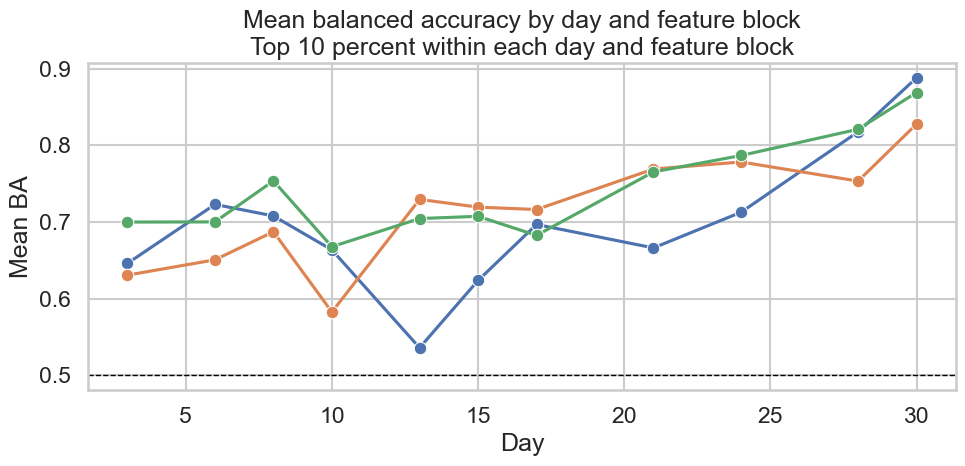

    Day FeatureClass   BA_mean
1     3        Mixed  0.699878
5     6   Morph_only  0.722926
7     8        Mixed  0.753611
10   10        Mixed  0.667759
12   13   Metab_only  0.729481
15   15   Metab_only  0.719370
18   17   Metab_only  0.716251
21   21   Metab_only  0.769048
25   24        Mixed  0.786764
28   28        Mixed  0.821013
32   30   Morph_only  0.888158


In [32]:
# # Mean Overall BA for each FeatureClass for the top 10% BA in each Feature each day (Supp Fig. S4)

top_frac = 0.1

# Keep only top 10 percent within each Day x FeatureClass
top10pct_df = (
    analysis_df
    .groupby(['Day', 'FeatureClass'], group_keys=False)
    .apply(lambda grp: grp.nlargest(max(1, int(np.ceil(len(grp) * top_frac))), 'BA_mean'))
    .reset_index(drop=True)
)

# Mean BA by day and feature block using only top 10 percent
abs_day = top10pct_df.groupby(['Day', 'FeatureClass'])['BA_mean'].mean().reset_index()

plot_day = abs_day.copy()
plot_day['FeatureClass'] = pd.Categorical(
    plot_day['FeatureClass'],
    ['Morph_only', 'Metab_only', 'Mixed']
)

# Best feature block by day using filtered top 10 percent summaries
best_block_df = (
    abs_day
    .sort_values(['Day', 'BA_mean'], ascending=[True, False])
    .groupby('Day')
    .head(1)
    .copy()
)

# Filter feature-day effects to match the same top-10-percent subset
# Assumes rows can be matched by index from analysis_df
#top10pct_idx = top10pct_df.index.tolist()

#feature_effects_top10pct = feature_day_effects.copy()

# If feature_day_effects already corresponds row-wise to analysis_df-derived summaries, use as-is only if already aggregated properly.
# Otherwise rebuild from the filtered source table if needed.
#feature_heatmap = feature_effects_top10pct.pivot(index='Feature', columns='Day', values='BA_delta_countmatched')

plt.figure(figsize=(10, 5))
sns.lineplot(data=plot_day, x='Day', y='BA_mean', hue='FeatureClass', marker='o', legend=False)
plt.axhline(0.5, color='black', linestyle='--', linewidth=1)
plt.title('Mean balanced accuracy by day and feature block\nTop 10 percent within each day and feature block')
plt.ylabel('Mean BA')
plt.tight_layout()
plt.savefig('./Supp Fig S4.png', dpi=220, bbox_inches='tight')
plt.show()

print(best_block_df)

  0%|          | 0/3 [00:00<?, ?it/s]

        Organoid  Day       Volume Classification Sub_Bad(z=-1.08)  \
47   BA1_96_1_A2   30  180559792.2           Good              NaN   
58   BA1_96_1_A3   30  175206117.0           Good              NaN   
68   BA1_96_1_A4   30  234688938.9           Good              NaN   
79   BA1_96_1_A5   30  179282359.8           Good              NaN   
100  BA1_96_1_A7   30  257670240.4           Good              NaN   

    Sub_Bad(z=0) Phase  GlucoseGlo_TL  GlutamateGlo_TL  LactateGlo_TL  ...  \
47           NaN    LD         1515.0              5.5            4.0  ...   
58           NaN    LD         1515.0              5.5            4.0  ...   
68           NaN    LD         1515.0              5.5            4.0  ...   
79           NaN    LD         1515.0              5.5            4.0  ...   
100          NaN    LD         1515.0              5.5            4.0  ...   

     AR_win_resid  Solidity_win_resid  Complexity_win_resid  Feret_win_resid  \
47      -0.015983           -0

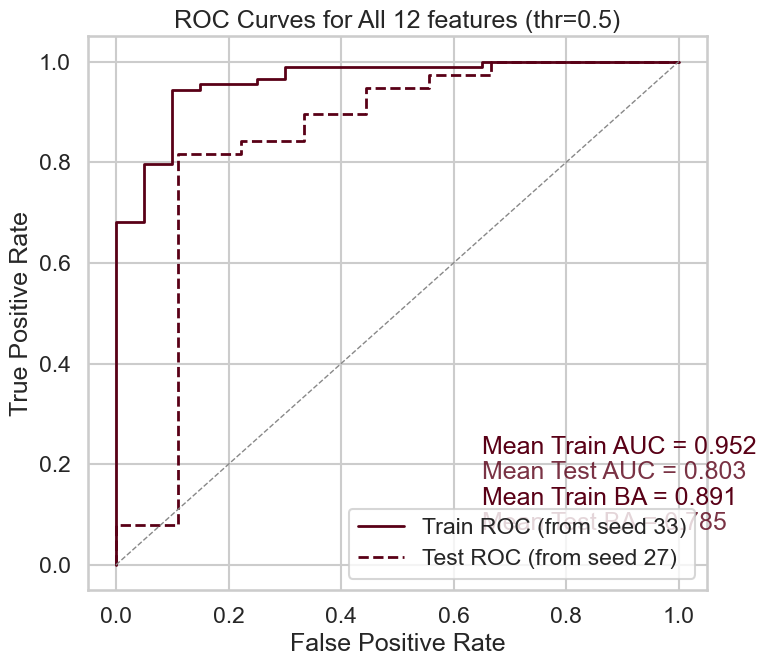

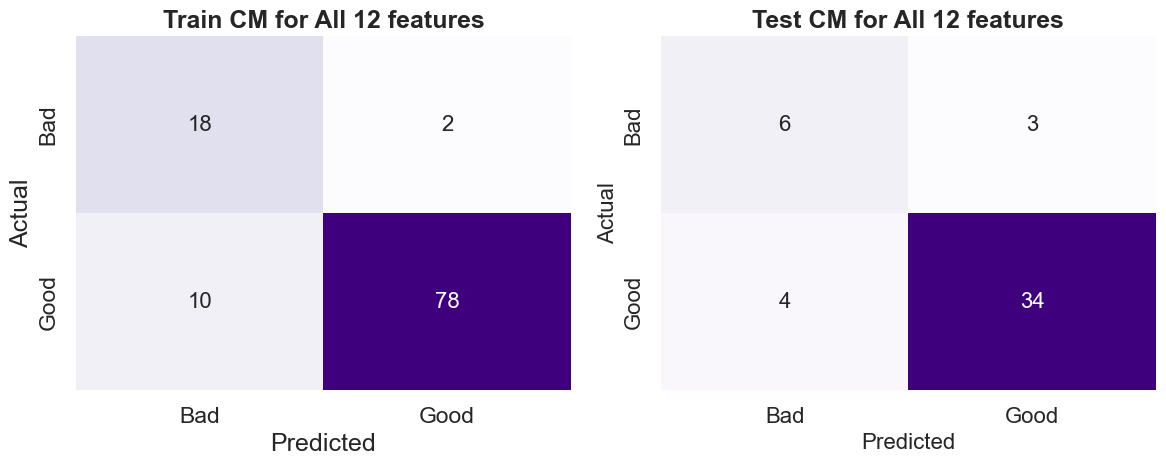

 33%|███▎      | 1/3 [00:00<00:01,  1.39it/s]

Seeds used: [20, 17, 75, 27, 33]
Threshold: 0.5
Mean Train AUC: 0.9524999999999999
Mean Test AUC: 0.8029239766081873
Mean Train BA: 0.8911363636363637
Mean Test BA: 0.7845029239766081
SD Train AUC: 0.009172925486641148
SD Test AUC: 0.10045210886574453
SD Train BA: 0.01312290912113824
SD Test BA: 0.07847269037031768
Per-seed Train AUC: [0.9392045454545455, 0.9579545454545454, 0.9607954545454545, 0.94375, 0.9607954545454546]
Per-seed Test AUC: [0.8801169590643275, 0.888888888888889, 0.6140350877192983, 0.8391812865497076, 0.7923976608187134]
Per-seed Train BA: [0.8988636363636364, 0.9102272727272727, 0.8795454545454545, 0.8738636363636363, 0.8931818181818182]
Per-seed Test BA: [0.8523391812865497, 0.8786549707602339, 0.6564327485380117, 0.7807017543859649, 0.7543859649122806]
        Organoid  Day       Volume Classification Sub_Bad(z=-1.08)  \
47   BA1_96_1_A2   30  180559792.2           Good              NaN   
58   BA1_96_1_A3   30  175206117.0           Good              NaN   
68   

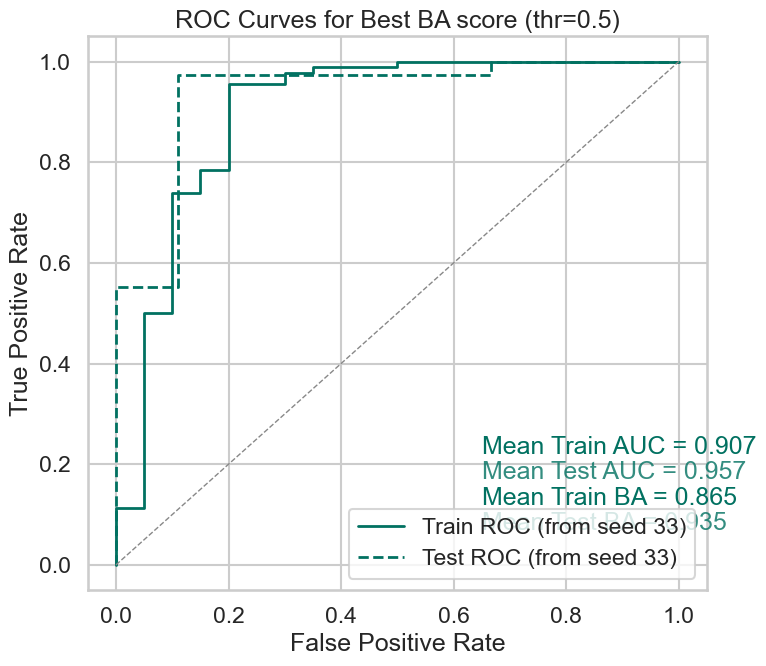

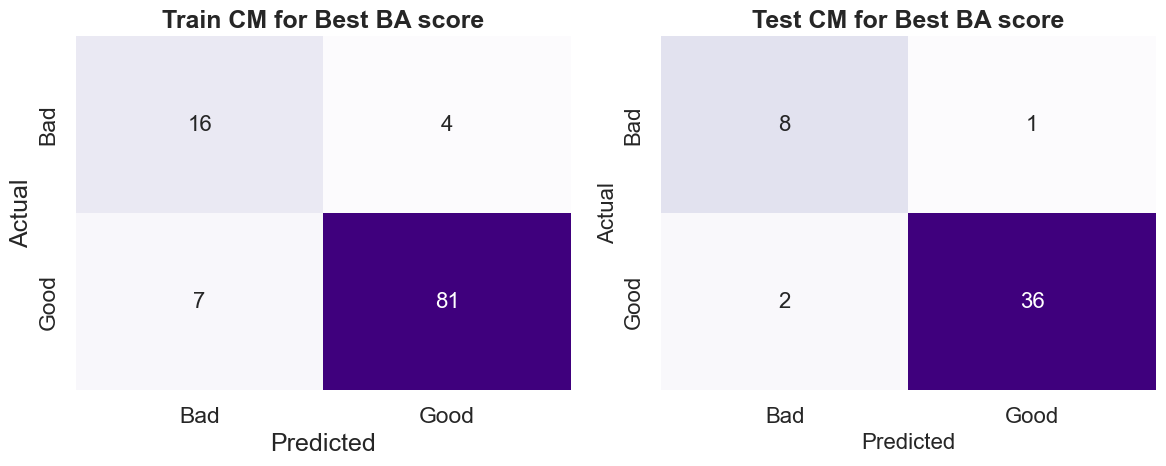

 67%|██████▋   | 2/3 [00:01<00:00,  1.41it/s]

Seeds used: [20, 17, 75, 27, 33]
Threshold: 0.5
Mean Train AUC: 0.9068181818181819
Mean Test AUC: 0.9567251461988304
Mean Train BA: 0.8645454545454546
Mean Test BA: 0.9350877192982455
SD Train AUC: 0.018710357541715846
SD Test AUC: 0.04443674910295408
SD Train BA: 0.012034729358976119
SD Test BA: 0.03981979516523319
Per-seed Train AUC: [0.9056818181818181, 0.9426136363636364, 0.8977272727272727, 0.8886363636363637, 0.8994318181818182]
Per-seed Test AUC: [0.9736842105263158, 0.8801169590643275, 0.9941520467836258, 1.0, 0.9356725146198831]
Per-seed Train BA: [0.8681818181818182, 0.8852272727272728, 0.8602272727272727, 0.8488636363636364, 0.8602272727272727]
Per-seed Test BA: [0.8918128654970761, 0.9049707602339181, 0.9605263157894737, 1.0, 0.9181286549707601]
        Organoid  Day       Volume Classification Sub_Bad(z=-1.08)  \
47   BA1_96_1_A2   30  180559792.2           Good              NaN   
58   BA1_96_1_A3   30  175206117.0           Good              NaN   
68   BA1_96_1_A4   30 

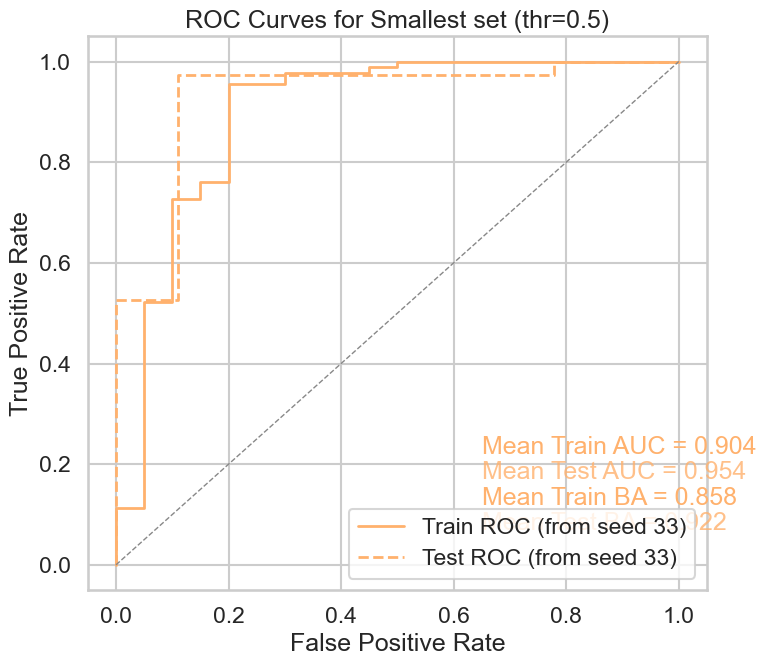

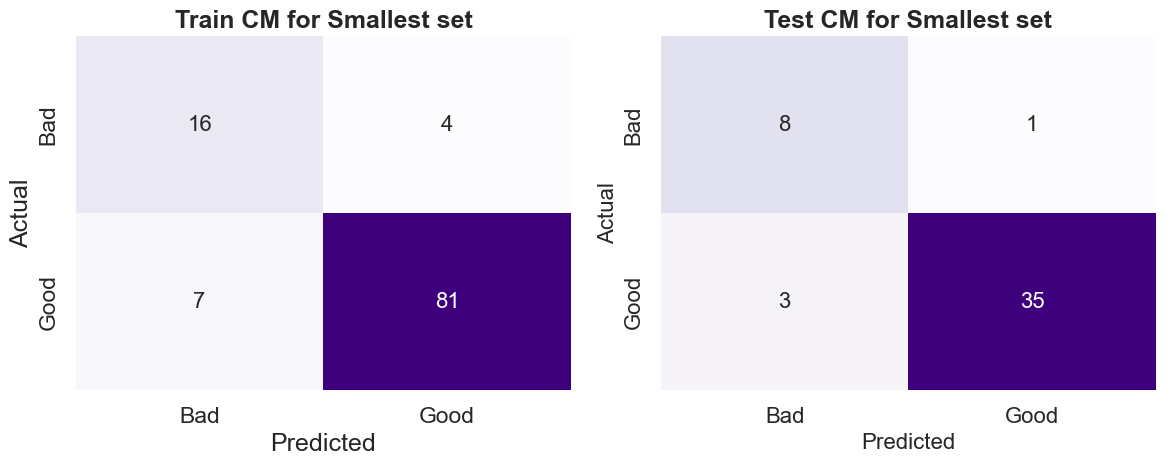

100%|██████████| 3/3 [00:02<00:00,  1.40it/s]

Seeds used: [20, 17, 75, 27, 33]
Threshold: 0.5
Mean Train AUC: 0.9043181818181818
Mean Test AUC: 0.9543859649122807
Mean Train BA: 0.8577272727272728
Mean Test BA: 0.9219298245614034
SD Train AUC: 0.01889441629006174
SD Test AUC: 0.0440968246117166
SD Train BA: 0.014541902975496712
SD Test BA: 0.044733975369679484
Per-seed Train AUC: [0.9034090909090909, 0.9403409090909092, 0.8943181818181818, 0.8857954545454545, 0.8977272727272727]
Per-seed Test AUC: [0.9736842105263158, 0.8801169590643275, 0.9883040935672515, 1.0, 0.9298245614035089]
Per-seed Train BA: [0.8738636363636363, 0.8681818181818182, 0.8545454545454545, 0.8318181818181818, 0.8602272727272727]
Per-seed Test BA: [0.8654970760233918, 0.9049707602339181, 0.9342105263157895, 1.0, 0.9049707602339181]


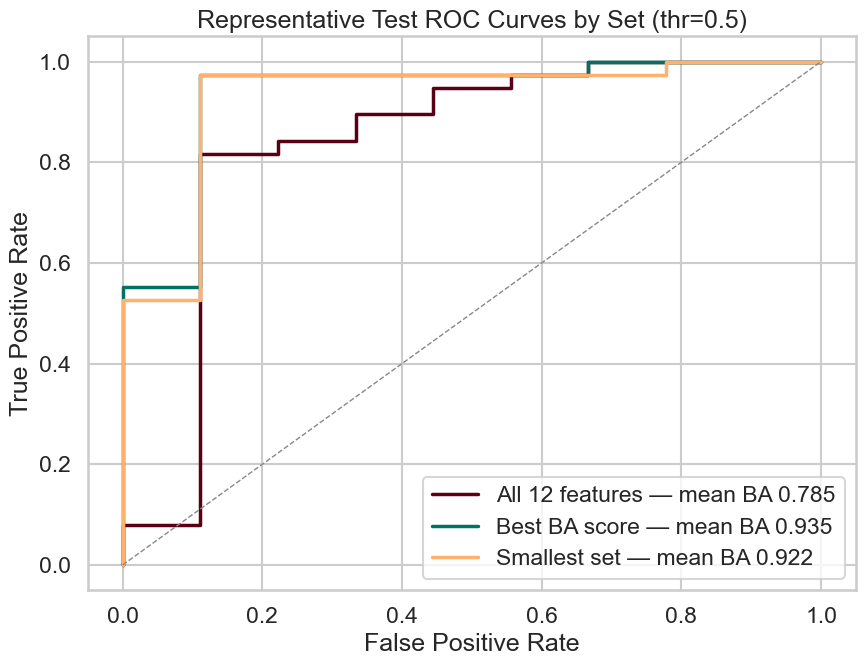

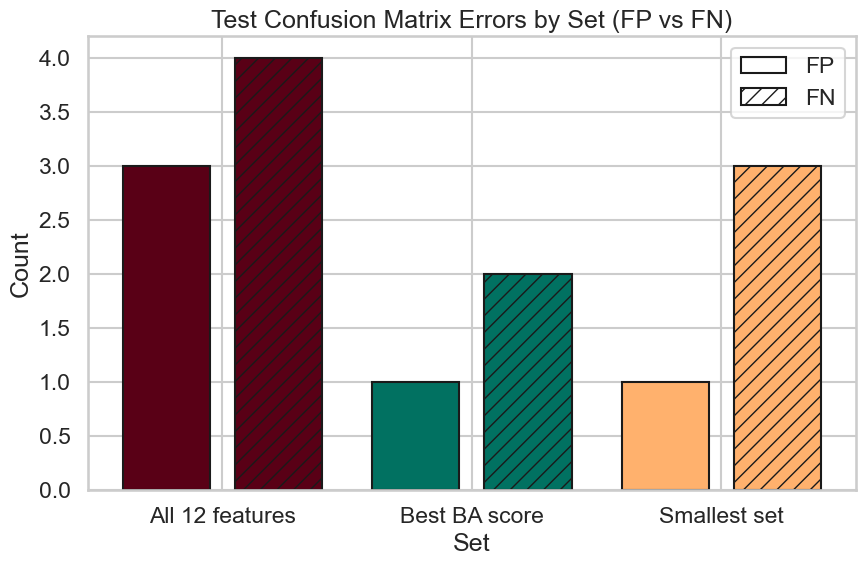

In [33]:
# Logistic regression over 5 seeds and report mean metrics for days 30 (Fig 6D and 6E)

# Run with 3 differente feature combinations
#   1) All
#   2) 'Area_win_log','AR_win','Feret_win','GlutamateGlo_win_vol_norm','PyruvateGlo_win_vol_norm','MalateGlo_win_vol_norm'
#   3) 'Area_win_log','Feret_win','GlutamateGlo_win_vol_norm','PyruvateGlo_win_vol_norm'
# - Show ROC representative curves from median BA scores (train and test) and report means
# - Show confusion heatmaps for the seed with median trains and test BA

all12_feats = ['Area_win_log','Circ._win','AR_win','Solidity_win','Complexity_win','Feret_win','GlucoseGlo_win_vol_norm','GlutamateGlo_win_vol_norm','LactateGlo_win_vol_norm','PyruvateGlo_win_vol_norm','MalateGlo_win_vol_norm','BCAAGlo_win_vol_norm']
combo2_feats = ['Area_win_log','AR_win','Feret_win','GlutamateGlo_win_vol_norm','PyruvateGlo_win_vol_norm','MalateGlo_win_vol_norm']
combo3_feats = ['Area_win_log','Feret_win','GlutamateGlo_win_vol_norm','PyruvateGlo_win_vol_norm']
feature_sets = {'All 12 features': all12_feats, 'Best BA score': combo2_feats, 'Smallest set': combo3_feats}

set_colors = {'All 12 features': '#590016', 'Best BA score': '#017161', 'Smallest set': '#ffb16d'}

rep_test_curves = []
fp_fn_by_set = []

seeds = [20, 17, 75, 27, 33]
bal_thr = 0.5

for set_name, feat_list in tqdm(feature_sets.items()):
  roc_color = set_colors.get(set_name, '#000000')
  mdl_df = df_sub[pd.to_numeric(df_sub['Day'], errors='coerce') == 30].copy()
  X = mdl_df[feat_list].values
  y = (mdl_df['Classification'] == 'Good').astype(int).values
  org = mdl_df['Organoid'].values

  # Guard for insufficient class balance
  if mdl_df["Classification"].nunique() < 2:
    continue

  print(mdl_df.head())
  print(mdl_df['Classification'].value_counts())

  auc_tr_list = []
  auc_te_list = []
  ba_tr_list = []
  ba_te_list = []
  cm_tr_list = []
  cm_te_list = []
  roc_data = []

  for rs in seeds:
      X_train, X_test, y_train, y_test = train_test_split(
          X, y, test_size=0.30, random_state=rs, stratify=y
      )
      pipe = Pipeline([
          ('scaler', StandardScaler()),
          ('lr', LogisticRegression(max_iter=2000, class_weight='balanced', solver='liblinear'))
      ])
      pipe.fit(X_train, y_train)
      p_train = pipe.predict_proba(X_train)[:,1]
      p_test = pipe.predict_proba(X_test)[:,1]

      fpr_tr, tpr_tr, _ = roc_curve(y_train, p_train)
      fpr_te, tpr_te, _ = roc_curve(y_test, p_test)
      auc_tr = auc(fpr_tr, tpr_tr)
      auc_te = auc(fpr_te, tpr_te)

      yhat_tr = (p_train >= bal_thr).astype(int)
      yhat_te = (p_test >= bal_thr).astype(int)
      ba_tr = balanced_accuracy_score(y_train, yhat_tr)
      ba_te = balanced_accuracy_score(y_test, yhat_te)

      cm_tr = confusion_matrix(y_train, yhat_tr)
      cm_te = confusion_matrix(y_test, yhat_te)

      auc_tr_list.append(auc_tr)
      auc_te_list.append(auc_te)
      ba_tr_list.append(ba_tr)
      ba_te_list.append(ba_te)
      cm_tr_list.append(cm_tr)
      cm_te_list.append(cm_te)
      roc_data.append((rs, fpr_tr, tpr_tr, fpr_te, tpr_te, auc_tr, auc_te, ba_tr, ba_te))

  # Means
  auc_tr_mean = float(np.mean(auc_tr_list))
  auc_te_mean = float(np.mean(auc_te_list))
  ba_tr_mean = float(np.mean(ba_tr_list))
  ba_te_mean = float(np.mean(ba_te_list))

  # Std Dev
  auc_tr_sd = float(np.std(auc_tr_list))
  auc_te_sd = float(np.std(auc_te_list))
  ba_tr_sd = float(np.std(ba_tr_list))
  ba_te_sd = float(np.std(ba_te_list))

  # Indices for median F1 seeds
  idx_med_te = int(np.argsort(ba_te_list)[len(ba_te_list)//2])
  idx_med_tr = int(np.argsort(ba_tr_list)[len(ba_tr_list)//2])
  rs_med_te = seeds[idx_med_te]
  rs_med_tr = seeds[idx_med_tr]

  # Extract ROC data for the two selected seeds
  rs_te, fpr_tr_te, tpr_tr_te, fpr_te_te, tpr_te_te, auc_tr_te, auc_te_te, ba_tr_te, ba_te_te = roc_data[idx_med_te]
  rs_tr, fpr_tr_tr, tpr_tr_tr, fpr_te_tr, tpr_te_tr, auc_tr_tr, auc_te_tr, ba_tr_tr, ba_te_tr = roc_data[idx_med_tr]

  # Save representative test ROC for this day
  rep_test_curves.append((set_name, fpr_te_te, tpr_te_te, ba_te_mean, rs_te))

  # Plot only two ROC curves: one for the median test F1 seed, one for the median train F1 seed
  plt.figure(figsize=(8,7))
  plt.plot(fpr_tr_tr, tpr_tr_tr, color=roc_color, lw=2, label='Train ROC (from seed ' + str(rs_med_tr) + ')')
  plt.plot(fpr_te_te, tpr_te_te, color=roc_color, lw=2, linestyle='dashed', label='Test ROC (from seed ' + str(rs_med_te) + ')')
  plt.plot([0,1],[0,1], color='#888888', lw=1, ls='--')
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('ROC Curves for ' + set_name + ' (thr=' + str(bal_thr) + ')')
  plt.legend(loc='lower right')
  # Annotate mean AUC and F1
  plt.text(0.65, 0.22, 'Mean Train AUC = ' + str(np.round(auc_tr_mean,3)), color=roc_color)
  plt.text(0.65, 0.17, 'Mean Test AUC = ' + str(np.round(auc_te_mean,3)), color=roc_color, alpha=0.8)
  plt.text(0.65, 0.12, 'Mean Train BA = ' + str(np.round(ba_tr_mean,3)), color=roc_color)
  plt.text(0.65, 0.07, 'Mean Test BA = ' + str(np.round(ba_te_mean,3)), color=roc_color, alpha=0.8)
  plt.tight_layout()
  plt.show()

  # Confusion matrices using those same seeds
  cm_tr_med = cm_tr_list[idx_med_tr]
  cm_te_med = cm_te_list[idx_med_te]

  # Track FP/FN for this day using the median test-F1 confusion matrix
  tn, fp, fn, tp = cm_te_med.ravel()
  fp_fn_by_set.append({
    'set': set_name,
    'fp': int(fp),
    'fn': int(fn)
  })

  fig, axes = plt.subplots(1, 2, figsize=(12,5))

  sns.heatmap(cm_tr_med, annot=True, fmt='d', cmap='Purples', cbar=False, ax=axes[0], annot_kws={"size": 16})
  axes[0].set_title('Train CM for ' + set_name, fontsize = 18, weight='bold')
  axes[0].set_xlabel('Predicted')
  axes[0].set_ylabel('Actual')
  axes[0].set_xticklabels(['Bad','Good'])
  axes[0].set_yticklabels(['Bad','Good'])

  sns.heatmap(cm_te_med, annot=True, fmt='d', cmap='Purples', cbar=False, ax=axes[1], annot_kws={"size": 16})
  axes[1].set_title('Test CM for ' + set_name, fontsize = 18, weight='bold')
  axes[1].set_xlabel('Predicted', fontsize = 16)
  axes[1].set_ylabel('Actual', fontsize = 16)
  axes[1].set_xticklabels(['Bad','Good'], fontsize = 16)
  axes[1].set_yticklabels(['Bad','Good'], fontsize = 16)
  plt.tight_layout()
  fig.canvas.draw()
  bbox = axes[1].get_tightbbox(fig.canvas.get_renderer())
  bbox_inches = bbox.transformed(fig.dpi_scale_trans.inverted())
  bbox_pad = bbox_inches.padded(0.1)
  plt.savefig('./Fig 6E - ' + set_name + '.png', dpi=220, bbox_inches=bbox_pad)
  plt.show()

  print('Seeds used: ' + str(seeds))
  print('Threshold: ' + str(bal_thr))
  print('Mean Train AUC: ' + str(auc_tr_mean))
  print('Mean Test AUC: ' + str(auc_te_mean))
  print('Mean Train BA: ' + str(ba_tr_mean))
  print('Mean Test BA: ' + str(ba_te_mean))
  print('SD Train AUC: ' + str(auc_tr_sd))
  print('SD Test AUC: ' + str(auc_te_sd))
  print('SD Train BA: ' + str(ba_tr_sd))
  print('SD Test BA: ' + str(ba_te_sd))
  print('Per-seed Train AUC: ' + str(auc_tr_list))
  print('Per-seed Test AUC: ' + str(auc_te_list))
  print('Per-seed Train BA: ' + str(ba_tr_list))
  print('Per-seed Test BA: ' + str(ba_te_list))

#Combined Test ROC Curves
plt.figure(figsize=(9, 7))
for (set_val, fpr_rep, tpr_rep, ba_mean_set, seed_rep) in rep_test_curves:
    color = set_colors.get(set_val, '#000000')
    label_txt = str(set_val) + " — mean BA " + str(np.round(ba_mean_set, 3))
    plt.plot(fpr_rep, tpr_rep, color=color, lw=2.5, label=label_txt)

# Chance diagonal
plt.plot([0, 1], [0, 1], color="#888888", lw=1, ls="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Representative Test ROC Curves by Set (thr=" + str(bal_thr) +")")
plt.legend(loc="lower right", frameon=True)
plt.tight_layout()
plt.savefig('./Fig 6D.png', dpi=220, bbox_inches='tight')
plt.show()

#Bar graph with FP and FN


# Sort by day for consistent ordering on the x-axis
fp_fn_sorted = sorted(fp_fn_by_set, key=lambda x: x['set'])
set_plot = [item['set'] for item in fp_fn_sorted]
fps = [item['fp'] for item in fp_fn_sorted]
fns = [item['fn'] for item in fp_fn_sorted]

x = np.arange(len(set_plot))
width = 0.35
offset = 0.05

plt.figure(figsize=(9, 6))
for i, set_val in enumerate(set_plot):
  color = set_colors.get(set_val, '#000000')
  # FP solid
  plt.bar(x[i] - offset - width/2, fps[i], width=width, color=color, edgecolor='k', label='FP' if i == 0 else None)
  # FN hatched
  plt.bar(x[i] + offset + width/2, fns[i], width=width, color=color, edgecolor='k', hatch='//', label='FN' if i == 0 else None)

#Legend style
fp_proxy = mpatches.Rectangle((0, 0), 1, 1, facecolor='none', edgecolor='k', linewidth=1.5)
fn_proxy = mpatches.Rectangle((0, 0), 1, 1, facecolor='none', edgecolor='k', hatch='//', linewidth=1.5)

plt.xticks(x, [str(dv) for dv in set_plot])
plt.xlabel('Set')
plt.ylabel('Count')
plt.title('Test Confusion Matrix Errors by Set (FP vs FN)')
plt.legend(handles=[fp_proxy, fn_proxy], labels=['FP', 'FN'], frameon=True, loc='best')
plt.tight_layout()
plt.show()

In [36]:
import session_info
session_info.show()